<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>99221 למידה מרובת סוכנים (MARL)</p>
<p>פרויקט סופי</p>
<p>שם: נדב פיירמן</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>נושא: מימוש והערכת Policy-Space Response Oracles (PSRO) — שמירת אוכלוסייה גדֵלה, פתירת המטא-משחק, ואימון תגובה מיטבית לפתרון.</p>
<p>שאלת המחקר: האם אוכלוסייה שנפתרת כמשחק חסינה יותר מ-self-play באותו תקציב? המדד: exploitability — כמה יריב מושלם מסוגל לסחוט.</p>
<p>הסביבה: Kuhn Poker — היחידה מבין המומלצות שבה ה-exploitability מחושב במדויק, ושיווי המשקל שלה ידוע אנליטית ומשמש לאימות.</p>
<p>הגישה: הפותר הוא האלגוריתם — self_play בקצה אחד, nash (double oracle) בשני. הזרועות חולקות oracle, תקציב והערכה: ההשוואה מבוקרת.</p>
<p>עיגון בספרות: כל מדד מאומת חיצונית — קבועי OpenSpiel, הפרמטרים של קון, ומדד נטול פותר. בנוסף: שחזור כשל מתועד ופירוק שגיאת PSRO.</p>
<p>הקוד באנגלית, ההסברים בעברית, וגרפים באנגלית בשל מגבלת עברית ב-matplotlib.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מפת המחברת:</p>
<ol>
<li>הכנה — ייבוא, הגדרות, חיבור ל-Drive וטעינת המודולים</li>
<li>הסביבה וסוכני הבסיס — חוקי המשחק, שלוש מדיניות בסיס, והתגמולים ביניהן</li>
<li>כלי המדידה — ערך מדויק, תגובה מיטבית ו-exploitability, מאומתים מול שיווי המשקל האנליטי. מוצגים מוקדם משום שכל השאר נשען עליהם</li>
<li>המטא-משחק האמפירי — אומד מצטבר עם שגיאות תקן ורווחי סמך</li>
<li>ה-response oracle — שלושה מימושים, מאומתים מול התגובה המיטבית המדויקת</li>
<li>פותרי המטא-אסטרטגיה — שמונה, מאומתים מול משחקים בעלי פתרון ידוע</li>
<li>ריצת PSRO מלאה — הלולאה מקצה לקצה, עם שמירה ושחזור</li>
<li>גבול ההתכנסות התיאורטי — double oracle עם חישוב מדויק לחלוטין, ותעודת ההתכנסות שהאלגוריתם עצמו משתמש בה</li>
<li>ראיות התנהגותיות — מה המדיניות שנלמדה משחקת בפועל, ואם היא נמצאת על הישר של Kuhn</li>
<li>חמישה ניסויים — ההשוואה המרכזית, הפותרים, האוכלוסייה, ה-oracle, וההכללה</li>
<li>שש אבלציות — פירוק התרומה של כל רכיב</li>
<li>סיכום ומסקנות</li>
</ol>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>1. הכנה</p>
<p>ייבוא — כל הייבוא מרוכז כאן:</p>
<ul>
<li>os, sys — נתיבים והוספת תיקיית הפרויקט ל-sys.path</li>
<li>time — מדידת זמן ההרצה של הניסויים ושל הפותרים</li>
<li>importlib — טעינה מחדש של מודולי הפרויקט ללא אתחול הסביבה</li>
<li>shutil — מחיקת תיקיית ה-checkpoint לאחר בדיקת השחזור</li>
<li>numpy — חשבון מטריצות, אקראיות ומדדים</li>
<li>pandas — טבלאות התוצאות וייצואן ל-CSV</li>
<li>scipy — תכנון ליניארי לפתרון נאש, התפלגות t לרווחי סמך, ומבחן t להשוואות</li>
<li>matplotlib — כל הגרפים; סגנון ggplot נקבע בשורה האחרונה</li>
<li>אין שימוש בשום ספריית RL חיצונית: ה-oracles, הפותרים, החישוב המדויק ולולאת ה-PSRO מומשו מאפס בקובצי ה-py של הפרויקט</li>
</ul>
</div>

In [1]:
import os
import sys
import time
import shutil
import importlib

import numpy as np
import pandas as pd
import scipy
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt

for module in (np, scipy, pd, matplotlib):
    print(f'{module.__name__:<12} {module.__version__}')

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 110
plt.style.use('ggplot')

numpy        2.1.3
scipy        1.16.3
pandas       2.2.3
matplotlib   3.10.0


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרות — כל הפרמטרים במקום אחד:</p>
<p>כללי</p>
<ul>
<li>SEED — הזרע הראשי; מקובע בסוף התא</li>
<li>NASH_ALPHA — הפרמטר הבוחר איבר ממשפחת שיווי המשקל האנליטית, בטווח [0, 1/3]</li>
<li>NASH_ALPHA_GRID — חמישה איברים מהמשפחה, לאימות שכולם נותנים אותו ערך משחק</li>
</ul>
<p>המטא-משחק (חלק ב)</p>
<ul>
<li>META_EPISODES — אפיזודות בכל בלוק הערכה של משבצת במטריצה</li>
<li>META_SEEDS — מספר הבלוקים הבלתי תלויים; שגיאת התקן מחושבת על פני ממוצעיהם</li>
<li>CONVERGENCE_EPISODES — סדרת גדלים לבדיקת קצב ההתכנסות של האומד</li>
</ul>
<p>ה-oracle (חלק ג)</p>
<ul>
<li>ORACLE_DEMO_BUDGETS — תקציבי אימון שבהם נבדק שה-oracle מגיע לתגובה המיטבית</li>
<li>REINFORCE_LR — קצב הלמידה של אומד הגרדיאנט</li>
</ul>
<p>ריצת ההדגמה (חלק ה)</p>
<ul>
<li>DEMO_SOLVER — פותר המטא בריצה המודגמת</li>
<li>DEMO_ITERATIONS — מספר איטרציות ה-PSRO</li>
<li>DEMO_ORACLE_BUDGET — אפיזודות אימון לכל תגובה מיטבית</li>
<li>DEMO_EPISODES, DEMO_SEEDS — תקציב ההערכה של המטא-משחק בריצה</li>
<li>SELF_PLAY_ROUNDS — סבבי התגובה המיטבית של לומד ה-self-play</li>
<li>MAX_EXACT_ITERATIONS — חסם איטרציות ל-double oracle המדויק, שאמור לעצור מעצמו הרבה לפניו</li>
</ul>
<p>הניסויים</p>
<ul>
<li>EXP1_SEEDS — חמישה זרעים בהשוואה המרכזית, כדי לאפשר מבחן סטטיסטי</li>
<li>EXP_SEEDS — חמישה זרעים גם בשאר הניסויים, מה שעונה על פריט הבונוס במפרט</li>
<li>ORACLE_BUDGETS — תקציבי ה-oracle הנבחנים בניסוי 4</li>
<li>TIMING_SIZES — גדלי אוכלוסייה למדידת עלות הפותרים</li>
<li>CONFIDENCE — רמת הביטחון של רווחי הסמך</li>
</ul>
</div>

In [2]:
SEED = 0
NASH_ALPHA = 1 / 6
NASH_ALPHA_GRID = (0.0, 1 / 12, 1 / 6, 0.25, 1 / 3)

META_EPISODES = 400
META_SEEDS = 5
CONVERGENCE_EPISODES = (50, 200, 800, 3200)

ORACLE_DEMO_BUDGETS = (2_000, 20_000)
REINFORCE_LR = 0.1

DEMO_SOLVER = 'nash'
DEMO_ITERATIONS = 12
DEMO_ORACLE_BUDGET = 5_000
DEMO_EPISODES = 400
DEMO_SEEDS = 5

SELF_PLAY_ROUNDS = 8
MAX_EXACT_ITERATIONS = 25

EXP1_SEEDS = range(5)
EXP_SEEDS = range(5)
ORACLE_BUDGETS = (500, 2_000, 10_000, 50_000)
TIMING_SIZES = (4, 8, 16, 32, 64)
CONFIDENCE = 0.95

np.random.seed(SEED)
print('SEED =', SEED)

SEED = 0


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חיבור ל-Google Drive, שבו יושבים קובצי ה-py של הפרויקט ותוצאות ריצות קודמות.</p>
</div>

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הגדרת נתיב הפרויקט והוספתו ל-sys.path, כדי שהתא הבא יוכל לייבא ממנו את המודולים. בסוף מודפסת רשימת הקבצים ונבדק אם תיקיית results כבר קיימת — אם כן, הניסויים בסעיף 10 ייטענו ממנה במקום לרוץ מחדש.</p>
</div>

In [4]:
PATH = '/content/drive/MyDrive/MARL/Final_Project'
RESULTS_PATH = os.path.join(PATH, 'results')

if PATH not in sys.path:
    sys.path.insert(0, PATH)

try:
    print('PATH:', os.listdir(PATH))
    print('Saved results present:', os.path.isdir(RESULTS_PATH))
except OSError as e:
    print(e)

PATH: ['oracles.py', 'exact.py', 'game.py', 'analysis.py', 'metagame.py', 'psro.py', 'experiments.py', 'metasolvers.py', 'test_psro.py', 'Multi_Agent_Reinforcement_Learning_Final_Project.ipynb']
Saved results present: False


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ייבוא משמונת מודולי ה-py של הפרויקט. המודולים מסודרים לפי חלקי המפרט וכל אחד נשען רק על אלה שלפניו; reload מבטיח שעריכות ייטענו בלי לאתחל את הסביבה. שמונים ותשע פונקציות ומחלקות, לפי מודול:</p>
<ul>
<li>game — המשחק, המדיניות והרצת אפיזודות (חלק א):
  <ul>
  <li>ZeroSumGame — הממשק המופשט: צומת מקרה, עץ החלטות, וקבוצות מידע שמסתירות ממה ששחקן אינו רואה.</li>
  <li>KuhnPoker — המימוש הקונקרטי: שלושה קלפים, סבב הימור יחיד, חמש היסטוריות מסתיימות.</li>
  <li>KUHN_GAME_VALUE — ערך המשחק האנליטי לשחקן 0 תחת משחק אופטימלי, 1/18-.</li>
  <li>kuhn_nash_policies — משפחת שיווי המשקל האנליטית, מפורמטרת ב-alpha.</li>
  <li>kuhn_heuristic — בייסליין היוריסטי: מהמר ומשלם רק עם המלך.</li>
  <li>kuhn_always_bet — בייסליין תוקפני: מהמר ומשלם תמיד.</li>
  <li>Policy — הממשק: מיפוי מקבוצת מידע להתפלגות על הפעולות החוקיות.</li>
  <li>RandomPolicy — אקראית אחידה על הפעולות החוקיות.</li>
  <li>TabularPolicy — טבלה מפורשת; זה מה שה-oracle מייצר ומה שנשמר לדיסק.</li>
  <li>MixturePolicy — מגרילה חבר אחד מהאוכלוסייה בתחילת כל אפיזודה, וזה בדיוק היריב שה-oracle חייב להתמודד מולו.</li>
  <li>policy_to_dict, policy_from_dict — סריאליזציה לצורך שמירה ושחזור.</li>
  <li>Policy.bet_probabilities — חתימת ההתנהגות: ההסתברות להמר בכל קבוצת מידע; להשוואת מדיניויות ולבדיקה מול פרמטרי Kuhn.</li>
  <li>transpose_policy — העברת מדיניות מכיסא אחד לשני, לצורך משחק דו-כיווני.</li>
  <li>head_to_head_matrix — מי-מנצח-את-מי, אנטי-סימטרית: ממוצעת על הכיסאות ונטולת יתרון פתיחה. רק עליה מחפשים מעגלים.</li>
  <li>payoff_distribution, sample_payoffs — אינטגרציית התגמול מהעץ ודגימה במקום יד-אחר-יד; זהה סטטיסטית ומהיר בהרבה.</li>
  <li>play_episode — הרצת אפיזודה בודדת והחזרת התגמול של שחקן 0.</li>
  <li>play_episode_trajectory — הרצה עם תיעוד החלטות הלומד, לצורך אימון.</li>
  <li>evaluate_pair — הרצת מספר אפיזודות והחזרת וקטור התגמולים.</li>
  </ul></li>
<li>exact — הכמויות המדויקות (סעיף 7):
  <ul>
  <li>exact_value — התוחלת המדויקת בין שתי מדיניות, במעבר על כל העץ ללא דגימה.</li>
  <li>exact_payoff_matrix — מטריצת התגמולים המדויקת לכל זוג מדיניות.</li>
  <li>mixture_value — ערך המטא-משחק, sigma0 כפול M כפול sigma1.</li>
  <li>enumerate_pure_strategies — מניית 64 האסטרטגיות הדטרמיניסטיות של שחקן.</li>
  <li>ExactBestResponse — מחשבון תגובה מיטבית עם מטמון גדל; ממקסם על האסטרטגיות הטהורות, שכן היא תמיד דטרמיניסטית.</li>
  <li>exploitability — ההגדרה מהמפרט, סכום שני פערי הסטייה, יחד עם הצורה המצומצמת התקפה בסכום אפס.</li>
  <li>population_exploitability — ה-exploitability הנמוך ביותר שהאוכלוסייה יכולה לבטא. נטול פותר, וזהו תנאי העצירה של double oracle.</li>
  <li>kuhn_behaviour_parameters — חילוץ חמשת פרמטרי Kuhn ממטא-אסטרטגיה, משוקללים בהסתברות ההגעה, לבדיקה מול הישר.</li>
  </ul></li>
<li>metagame — המטא-משחק האמפירי (חלק ב):
  <ul>
  <li>EmpiricalMetaGame — מטריצת התגמולים הנאמדת: אומדת תוחלת ושגיאת תקן, ומוסיפה מדיניות בלי לחשב קיימים מחדש.</li>
  <li>dominated_policies — מדיניות שנשלטות על ידי מדיניות אחרת יחידה.</li>
  <li>cycle_strength — מדידת אי-טרנזיטיביות: ספירת מעגלים בני שלושה. דורשת מטריצה אנטי-סימטרית.</li>
  <li>EmpiricalMetaGame(exact=True) — כל משבצת מחושבת מהעץ במקום להידגם. עם ExactOracle הופך PSRO ל-double oracle.</li>
  </ul></li>
<li>oracles — ה-response oracles (חלק ג):
  <ul>
  <li>Oracle — מחלקת הבסיס המופשטת; החתימה המשותפת שכל שלושת האורקלים מממשים.</li>
  <li>OracleResult — מה שאורקל מחזיר: המדיניות שנלמדה, מספר האפיזודות, התגמול הממוצע וזמן האימון.</li>
  <li>TabularQLearningOracle — Q-learning על קבוצות מידע, עם קצב למידה מבוסס ספירות שמונע הרעבת חקירה.</li>
  <li>ReinforceOracle — policy gradient עם baseline מתגלגל; מייצר מדיניות סטוכסטית, מה שחשוב במשחק ששיווי המשקל שלו מעורב.</li>
  <li>ExactOracle — תגובה מיטבית מדויקת במניית אסטרטגיות; גבול ה-oracle המושלם, והופך את הלולאה לאלגוריתם ה-double oracle.</li>
  <li>get_oracle — בחירת oracle לפי שם, לשימוש בקונפיגורציה.</li>
  <li>self_play_baseline — קבוצת הביקורת: תגובה מיטבית חוזרת לעצמה בלי אוכלוסייה כלל, ותיעוד המחזוריות שנוצרת.</li>
  </ul></li>
<li>metasolvers — פותרי המטא-אסטרטגיה (חלק ד):
  <ul>
  <li>uniform — הסתברות שווה לכל מדיניות באוכלוסייה.</li>
  <li>self_play — כל המסה על המדיניות האחרונה; קבוצת הביקורת של הפרויקט.</li>
  <li>fictitious_play — תגובה מיטבית להתפלגות האמפירית של העבר.</li>
  <li>solve_zero_sum_nash — פתרון מדויק של משחק מטריצה בסכום אפס בתכנון ליניארי.</li>
  <li>nash — שיווי משקל של המטא-משחק; זהו אלגוריתם ה-double oracle.</li>
  <li>replicator — דינמיקת רפליקטור בזמן בדיד.</li>
  <li>projected_replicator — רפליקטור עם רצפת הסתברות, כלומר חקירה כפויה.</li>
  <li>regret_matching — הסתברויות ביחס לחרטה החיובית המצטברת.</li>
  <li>rectified_nash — PSRO_rN: אימון רק מול יריבים שהלומד אינו מפסיד להם. נכלל דווקא משום שהוא נכשל, וסעיף 10.2.1 משחזר זאת.</li>
  <li>strategy_entropy — אנטרופיית שאנון של המטא-אסטרטגיה.</li>
  <li>SOLVERS, get_solver — מילון כל הפותרים ובחירה לפי שם.</li>
  </ul></li>
<li>psro — הלולאה (חלק ה):
  <ul>
  <li>PSROConfig — כל פרמטרי הריצה באובייקט אחד הניתן לסריאליזציה.</li>
  <li>IterationRecord — כל מה שנמדד באיטרציה בודדת.</li>
  <li>PSRO — הלולאה: השלמת המשבצות החסרות, פתירת המטא-משחק, אימון תגובה מיטבית והוספתה לאוכלוסייה. כוללת שמירה ושחזור.</li>
  </ul></li>
<li>analysis — גיוון וגרפים (סעיפים 6 ו-7):
  <ul>
  <li>jensen_shannon — הדיברגנץ בין שתי התפלגויות, בביטים.</li>
  <li>action_js_divergence — כמה שונה שתי מדיניות פועלות באותן קבוצות מידע.</li>
  <li>visitation_distribution — ההסתברות המדויקת להגיע לכל קבוצת מידע.</li>
  <li>visitation_js_divergence — כמה שונה הן מנווטות את המשחק.</li>
  <li>response_profile — התגמול המדויק מול כל יריב בקבוצה קבועה.</li>
  <li>response_profile_distance — כמה שונה הן מנקדות מול אותם יריבים; זו התפיסה המשמעותית אסטרטגית.</li>
  <li>pairwise_matrix, population_diversity — מטריצת המרחקים וסיכומה.</li>
  <li>marginal_diversity — כמה התנהגות חדשה כל מדיניות הוסיפה ביחס לקודמותיה.</li>
  <li>plot_exploitability, plot_metric_by_iteration — עקומות עם רצועת שגיאת תקן.</li>
  <li>plot_payoff_heatmap — מפת חום של המטא-משחק עם סימון התמיכה.</li>
  <li>plot_summary_bars, plot_tradeoff, plot_generalisation, plot_marginal_diversity — שאר הגרפים.</li>
  <li>behavioural_profile, classify_hand, play_example_hands — סיווג ידיים והצגת דוגמאות משחק, לראיות ההתנהגותיות של סעיף 9.</li>
  <li>unique_policy_count — כמה מדיניויות באוכלוסייה שונות באמת. מדד Muller ואחרים, שמזהה את הלולאה של PSRO_rN.</li>
  <li>effective_diversity — המדד של Balduzzi ואחרים: המרווח המשוקלל שבו הסוכנים בתמיכת שיווי המשקל מנצחים זה את זה.</li>
  <li>dpp_expected_cardinality — הקרדינליות הצפויה של תהליך נקודתי דטרמיננטלי, המדד של Perez-Nieves ואחרים; עמיד לכפילויות.</li>
  <li>iqm, bootstrap_ci, probability_of_improvement — בסגנון Agarwal: ממוצע בין-רבעוני, רווח בוטסטרפ וגודל אפקט במקום p.</li>
  </ul></li>
<li>experiments — הניסויים והאבלציות (סעיפים 6 ו-8):
  <ul>
  <li>RunSpec — מפרט ריצה בודדת, כל מה שנדרש כדי לשחזרה.</li>
  <li>run_one, run_many — הרצת ריצה בודדת, והרצת קבוצת ריצות במקביל.</li>
  <li>initial_population — האוכלוסייה שממנה PSRO מתחיל.</li>
  <li>random_policy_set, perturb — יריבים שלא נראו באימון, ויריבים מופרעים.</li>
  <li>evaluate_agent — ניקוד מטא-אסטרטגיה מול קבוצת יריבים: ממוצע, מקרה גרוע ורגישות.</li>
  <li>experiment_1 עד experiment_5, ablations — חמשת הניסויים ושש האבלציות; כל אחד שומר תוצאותיו ל-CSV ונטען בהרצה חוזרת.</li>
  </ul></li>
</ul>
</div>

In [5]:
import game as game_module
import exact, metagame, metasolvers, oracles, psro, analysis, experiments

for module in (game_module, exact, metagame, metasolvers, oracles, psro,
               analysis, experiments):
    importlib.reload(module)

from game import (KuhnPoker, KUHN_GAME_VALUE, kuhn_nash_policies,
                  kuhn_heuristic, kuhn_always_bet,
                  RandomPolicy, TabularPolicy, MixturePolicy)
from exact import (exact_value, exact_payoff_matrix, mixture_value,
                   enumerate_pure_strategies, ExactBestResponse, exploitability,
                   population_exploitability, kuhn_behaviour_parameters)
from metagame import EmpiricalMetaGame, dominated_policies, cycle_strength
from metasolvers import SOLVERS, solve_zero_sum_nash, strategy_entropy
from oracles import TabularQLearningOracle, ReinforceOracle, ExactOracle
from psro import PSRO, PSROConfig

game = KuhnPoker()
print('Game               :', game.name)
print('Player 0 infosets  :', game.all_infosets(0))
print('Player 1 infosets  :', game.all_infosets(1))
print('Pure strategies    :', game.num_pure_strategies(0), 'per player')
print('Analytic value     :', round(KUHN_GAME_VALUE, 6))

Game               : kuhn_poker
Player 0 infosets  : ('0', '1', '2', '0pb', '1pb', '2pb')
Player 1 infosets  : ('0p', '1p', '2p', '0b', '1b', '2b')
Pure strategies    : 64 per player
Analytic value     : -0.055556


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שש קבוצות מידע לכל שחקן, ולכן 64 אסטרטגיות דטרמיניסטיות — מספיק מעט כדי למנות את כולן, ולכן התגובה המיטבית וה-exploitability יוצאים מדויקים ולא מוערכים. השורה האחרונה, 1/18-, היא ערך המשחק האנליטי שמולו נמדד כל אימות בהמשך.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>2. הסביבה וסוכני הבסיס (חלק א' במפרט)</p>
<p>Kuhn Poker: שלושה קלפים J&lt;Q&lt;K, כל שחקן מניח אנטה של 1 ומקבל קלף אחד. לכל שחקן שתי פעולות, p ו-b, ומשמעותן תלויה בהקשר: p הוא check כשאין הימור על השולחן ו-fold כשיש, ו-b הוא bet או call. חמש היסטוריות מסתיימות בלבד, ולכן אפשר לפרוש את כולן בטבלה ולאמת ידנית.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חמש ההיסטוריות המסתיימות, מה כל אחת אומרת במילים, והתגמול לשחקן 0 עם הקלף הגבוה ועם הנמוך. נבדק שצומת המקרה מסתכם ל-1.</p>
</div>

In [6]:
rows = []
for history, meaning in [
    (('p', 'p'), 'both check, showdown for a pot of 2'),
    (('p', 'b', 'p'), 'P0 checks, P1 bets, P0 folds'),
    (('p', 'b', 'b'), 'P0 checks, P1 bets, P0 calls'),
    (('b', 'p'), 'P0 bets, P1 folds'),
    (('b', 'b'), 'P0 bets, P1 calls, showdown for a pot of 4'),
]:
    rows.append({
        'history': ''.join(history),
        'meaning': meaning,
        'P0 holds K vs J': game.terminal_value((2, 0), history),
        'P0 holds J vs K': game.terminal_value((0, 2), history),
    })
terminal_table = pd.DataFrame(rows)
display(terminal_table)

deals = game.chance_outcomes()
print(f'Deals: {len(deals)}, each with probability {deals[0][1]:.4f}, '
      f'total {sum(prob for _c, prob in deals):.4f}')

,history,meaning,P0 holds K vs J,P0 holds J vs K
0,pp,"both check, showdown for a pot of 2",1.0,-1.0
1,pbp,"P0 checks, P1 bets, P0 folds",-1.0,-1.0
2,pbb,"P0 checks, P1 bets, P0 calls",2.0,-2.0
3,bp,"P0 bets, P1 folds",1.0,1.0
4,bb,"P0 bets, P1 calls, showdown for a pot of 4",2.0,-2.0


Deals: 6, each with probability 0.1667, total 1.0000


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח טבלת ההיסטוריות:</p>
<ul>
<li>התגמולים סימטריים בדיוק כמצופה: ב-showdown הסימן מתהפך בין שני המקרים, ובקיפול (pbp ו-bp) התגמול קבוע ואינו תלוי בקלפים כלל</li>
<li>הקיפול pbp מפסיד 1- גם כשבידי שחקן 0 המלך — מי שמקפל מפסיד את האנטה ולא משנה מה החזיק, וזה מה שמאפשר בלוף</li>
<li>הגודל הוא 1 כשרק האנטות בקופה ו-2 כשהימור נענה, בלי ערכי ביניים: כל התגמולים במשחק הם {1±, 2±}</li>
<li>שש חלוקות שוות הסתברות שסכומן בדיוק 1 — צומת המקרה תקין</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושת סוכני הבסיס שהמפרט דורש בחלק א'. שניים מהם נכתבים ביד, והשלישי נלמד:</p>
<ul>
<li>random — מדיניות אקראית אחידה. קו הבסיס התחתון</li>
<li>tight — היוריסטיקה פשוטה: מהמר ומשלם רק עם המלך, אחרת check או קיפול</li>
<li>self_play — לומד בעל מדיניות יחידה: מחליף אותה שוב ושוב בתגובה מיטבית לעצמה, בלי לזכור דבר. זהו קו הביקורת שמולו נמדד PSRO</li>
</ul>
<p>מוצגים גם שני סוכנים שאינם נדרשים: aggro, שמהמר תמיד ומדגים כמה קל לנצל מדיניות צפויה, ו-nash, שיווי המשקל האנליטי כאמת מידה עליונה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מאמן את לומד ה-self-play, מציג את ה-exploitability של כל מדיניות שהוא מייצר בדרך, ובודק אם חזר למדיניות שכבר ייצר.</p>
</div>

Self-play learner: exploitability of each successive policy


,round,exploitability of that iterate
0,1,0.5000
1,2,0.1667
2,3,0.3333
3,4,0.3333
4,5,0.5000
5,6,0.1667
6,7,0.3333
7,8,0.3333


Revisited a policy it had already produced: True


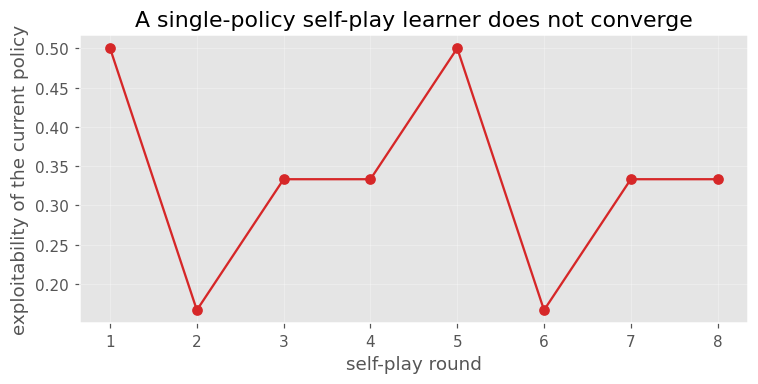

In [7]:
self_play_result = oracles.self_play_baseline(game, 0, rounds=SELF_PLAY_ROUNDS,
                                              budget=DEMO_ORACLE_BUDGET, seed=SEED)
self_play0 = self_play_result.policy
self_play1 = oracles.self_play_baseline(game, 1, rounds=SELF_PLAY_ROUNDS,
                                        budget=DEMO_ORACLE_BUDGET, seed=SEED).policy

trace = pd.DataFrame({
    'round': range(1, len(self_play_result.extra['history']) + 1),
    'exploitability of that iterate': np.round(self_play_result.extra['history'], 4),
})
print('Self-play learner: exploitability of each successive policy')
display(trace)
print('Revisited a policy it had already produced:',
      self_play_result.extra['returned'])

plt.figure(figsize=(7, 3.6))
plt.plot(trace['round'], trace['exploitability of that iterate'],
         marker='o', color='#d62728')
plt.xlabel('self-play round')
plt.ylabel('exploitability of the current policy')
plt.title('A single-policy self-play learner does not converge')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח לומד ה-self-play:</p>
<ul>
<li>הרצף מחזורי ולא יורד, במחזור 4: סיבובים 5 עד 8 משחזרים את 1 עד 4. הדגל returned מאשר — הלומד ייצר מדיניות קודמת</li>
<li>המנגנון: כל סבב מייצר תגובה מיטבית ליריב ומוחק את הקודם. במשחק לא-טרנזיטיבי, כפי שנראה בהמשך, האיטרציה חייבת להסתובב במעגל</li>
<li>הטובה ביותר, 1/6, בסיבוב 2 ואובדת מיד; האחרון גרוע פי שניים. הלומד אינו יודע, כי אין אוכלוסייה להשוות — וזה מה ש-PSRO מוסיף</li>
<li>זהו לב הבעיה, ונראה כאן נקי יותר מאשר בזרוע ה-self-play בהמשך: אין רעש הערכה, כי התגובה המיטבית מחושבת מול מדיניות יחידה</li>
<li>לכן גם הערכים יוצאים שברים מדויקים (1/2, 1/6, 1/3) — כל איטרציה היא תגובה מיטבית מדויקת למדיניות דטרמיניסטית</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מטריצת התגמולים בין סוכני הבסיס, עם הממוצע, הגרוע והטוב, וגרף שמעמיד ממוצע מול גרוע. מחושבת על עץ המשחק ולא בדגימה, נטולת רעש.</p>
</div>

Exact payoff to player 0 (rows) against player 1 (columns):


,random,tight,self_play,aggro,nash
random,0.1250,-0.0833,0.1250,-0.2500,-0.1667
tight,0.0000,0.0000,0.0000,0.0000,-0.0556
self_play,0.5000,0.0000,0.5000,0.0000,-0.1111
aggro,0.5000,0.0000,0.5000,0.0000,-0.1111
nash,0.1111,-0.0556,0.0278,0.1111,-0.0556


Summary per baseline, as player 0:


,mean,worst case,best case
random,-0.0500,-0.2500,0.1250
tight,-0.0111,-0.0556,0.0000
self_play,0.1778,-0.1111,0.5000
aggro,0.1778,-0.1111,0.5000
nash,0.0278,-0.0556,0.1111


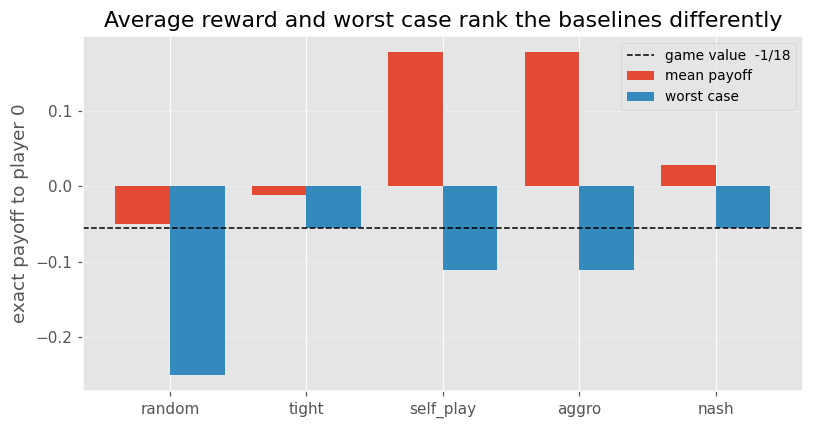

In [8]:
nash0, nash1 = kuhn_nash_policies(alpha=NASH_ALPHA)

baselines0 = [RandomPolicy('random'), kuhn_heuristic(0, 'tight'), self_play0,
              kuhn_always_bet(0, 'aggro'), nash0]
baselines1 = [RandomPolicy('random'), kuhn_heuristic(1, 'tight'), self_play1,
              kuhn_always_bet(1, 'aggro'), nash1]
names = ['random', 'tight', 'self_play', 'aggro', 'nash']

baseline_matrix = exact_payoff_matrix(game, baselines0, baselines1)

print('Exact payoff to player 0 (rows) against player 1 (columns):')
display(pd.DataFrame(baseline_matrix, index=names, columns=names).round(4))

print('Summary per baseline, as player 0:')
display(pd.DataFrame({
    'mean': baseline_matrix.mean(axis=1).round(4),
    'worst case': baseline_matrix.min(axis=1).round(4),
    'best case': baseline_matrix.max(axis=1).round(4),
}, index=names))

fig, ax = plt.subplots(figsize=(7.5, 4))
positions = np.arange(len(names))
ax.bar(positions - 0.2, baseline_matrix.mean(axis=1), 0.4, label='mean payoff')
ax.bar(positions + 0.2, baseline_matrix.min(axis=1), 0.4, label='worst case')
ax.axhline(KUHN_GAME_VALUE, color='black', linestyle='--', linewidth=1,
           label='game value  -1/18')
ax.set_xticks(positions)
ax.set_xticklabels(names)
ax.set_ylabel('exact payoff to player 0')
ax.set_title('Average reward and worst case rank the baselines differently')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח מטריצת הבסיס:</p>
<ul>
<li>שורות self_play ו-aggro זהות ספרה בספרה. לומד ה-self-play התכנס למדיניות שמהמרת תמיד — האבחנה הקודמת, מאומתת מספרית</li>
<li>aggro ו-self_play שולטים ב-random בכל העמודות, אך אף אחד אינו שולט ב-tight או ב-nash — כלומר אין פתרון דטרמיניסטי למשחק</li>
<li>הגרף מראה היפוך: לפי הממוצע aggro ו-self_play מובילים, לפי המקרה הגרוע הם נופלים מתחת ל-1/18- בעוד tight ו-nash לא</li>
<li>המקרה הגרוע חלקי: על חמישה יריבים, ולפיו tight ו-nash שקולים. תגובה מיטבית לוקחת מ-tight 1/6 ומ-nash כלום — וזה בדיוק exploitability</li>
<li>עמודת nash שלילית כולה: אף בייסליין אינו מנצח יריב בשיווי משקל. הטוב ביותר שמישהו משיג מולו הוא 0.0556- שהם 1/18-, ערך המשחק</li>
<li>random החלש ביותר, עם 0.25- מול aggro. וזו מלכודת ה-self-play: aggro גובה את הפער הגדול, ודווקא משום שהוא צפוי קל לנצלו</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>3. כלי המדידה — אימות מול אמת ידועה (סעיף 7 במפרט)</p>
<p>ערך המשחק של Kuhn ידוע אנליטית, 1/18-. לשחקן 0 משפחה חד-פרמטרית של שיווי משקל עם alpha בטווח [0, 1/3], ולשחקן 1 שיווי משקל יחיד. כל איבר במשפחה חייב להניב את אותו ערך ו-exploitability אפס.</p>
<p>ה-exploitability מוגדר במפרט כסכום שני פערי הסטייה, ובסכום אפס מצטמצם לסכום ערכי התגובה המיטבית. שתי הצורות נבדקות זו מול זו.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>חמשת איברי משפחת שיווי המשקל, עם ערך המשחק, ה-exploitability והתגובה המיטבית. וכמה יריב מושלם סוחט מכל בייסליין — בטבלה ובגרף.</p>
</div>

,alpha,game value,exploitability,BR player 0,BR player 1,error vs analytic
0,0.0000,-0.055556,8.326673e-17,-0.055556,0.055556,2.775558e-17
1,0.0833,-0.055556,2.775558e-17,-0.055556,0.055556,1.387779e-16
2,0.1667,-0.055556,1.110223e-16,-0.055556,0.055556,0.000000e+00
3,0.2500,-0.055556,1.110223e-16,-0.055556,0.055556,2.775558e-17
4,0.3333,-0.055556,1.110223e-16,-0.055556,0.055556,0.000000e+00


Analytic game value: -0.0555555556
Largest error      : 1.39e-16


,opponent (player 1),best response value for player 0
0,random,0.5000
1,tight,0.1667
2,self_play,0.5833
3,aggro,0.3333
4,nash,-0.0556


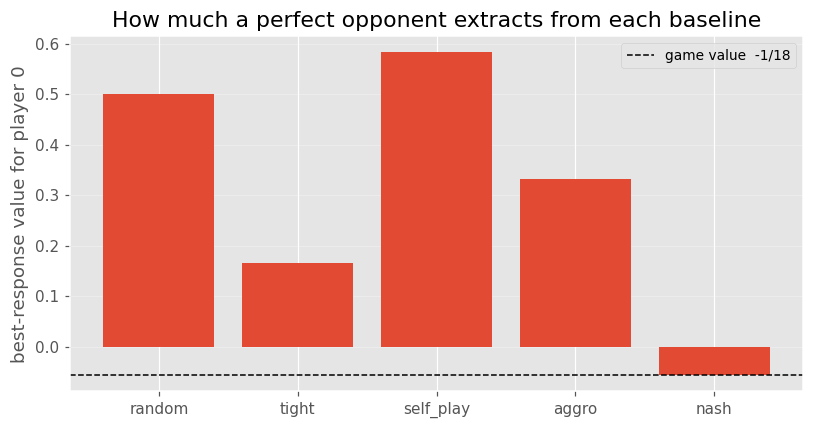

In [9]:
br0 = ExactBestResponse(game, 0)
br1 = ExactBestResponse(game, 1)

rows = []
for alpha in NASH_ALPHA_GRID:
    policy0, policy1 = kuhn_nash_policies(alpha)
    result = exploitability(game, [policy0], [1.0], [policy1], [1.0], br0, br1)
    rows.append({'alpha': round(alpha, 4),
                 'game value': round(result['value0'], 10),
                 'exploitability': result['exploitability'],
                 'BR player 0': round(result['br0'], 6),
                 'BR player 1': round(result['br1'], 6),
                 'error vs analytic': abs(result['value0'] - KUHN_GAME_VALUE)})
equilibrium_table = pd.DataFrame(rows)
display(equilibrium_table)

print(f'Analytic game value: {KUHN_GAME_VALUE:.10f}')
print(f'Largest error      : {equilibrium_table["error vs analytic"].max():.2e}')

best_response_table = pd.DataFrame([
    {'opponent (player 1)': name,
     'best response value for player 0':
         round(br0.best_response_value([policy], [1.0]), 4)}
    for name, policy in zip(names, baselines1)
])
display(best_response_table)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(best_response_table['opponent (player 1)'],
       best_response_table['best response value for player 0'])
ax.axhline(KUHN_GAME_VALUE, color='black', linestyle='--', linewidth=1,
           label='game value  -1/18')
ax.set_ylabel('best-response value for player 0')
ax.set_title('How much a perfect opponent extracts from each baseline')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח משפחת שיווי המשקל:</p>
<ul>
<li>כל חמשת איברי המשפחה מניבים בדיוק 1/18- ו-exploitability בדיוק מכונה (1e-16). האימות החזק ביותר במחברת: המדד המרכזי נכון</li>
<li>שני ערכי התגובה המיטבית בשיווי המשקל 0.0556- ו-0.0556+ בדיוק, כלומר סכומם אפס — הזהות שתקפה בסכום אפס מתקיימת מספרית</li>
<li>הגרף מהפך את הדירוג הקודם: self_play הניתן לניצול ביותר, 0.583, גרוע אפילו מ-random. אימון מול העצמי ייצר משהו פגיע מאקראי</li>
<li>nash הוא העמודה היחידה שנחה על הקו: תגובה מיטבית אינה סוחטת ממנו דבר מעבר לערך המשחק. זו ההגדרה של שיווי משקל, וזה היעד</li>
<li>היכולת לדווח exploitability מדויק ולא משוער היא הסיבה לבחירת Kuhn Poker. המפרט: מי שמדווח רק תגמול ממוצע אינו מקבל ציון מלא</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>3.1 מוסכמת ההגדרה ואימות מול קבועים מפורסמים</p>
<p>בספרות exploitability משמש לשני גדלים שנבדלים בפקטור 2: Lanctot ואחרים (2017) כסכום, ו-OpenSpiel כחצי מזה. המפרט מגדיר סכום, ולכן כל מספר במחברת הוא NashConv, והטבלה מדווחת גם את הצורה החצויה. שני הקבועים — 11/12 למדיניות אחידה ו-2 לוויתור תמידי — לקוחים מערכת הבדיקה של OpenSpiel.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שלושה זוגות מדיניות שערכם ידוע מראש: אחידה, ויתור תמידי ושיווי משקל. לכל אחד ה-NashConv המחושב, ערך הייחוס, השגיאה, והצורה החצויה.</p>
</div>

In [10]:
reference = [
    ('uniform random', RandomPolicy('u0'), RandomPolicy('u1'), 11 / 12),
    ('always pass', TabularPolicy.from_bet_probabilities(
        game, 0, {i: 0.0 for i in game.all_infosets(0)}, name='pass0'),
     TabularPolicy.from_bet_probabilities(
         game, 1, {i: 0.0 for i in game.all_infosets(1)}, name='pass1'), 2.0),
]
nash0_ref, nash1_ref = kuhn_nash_policies(alpha=NASH_ALPHA)
reference.append(('nash equilibrium', nash0_ref, nash1_ref, 0.0))

rows = []
for name, policy0, policy1, expected in reference:
    result = exploitability(game, [policy0], [1.0], [policy1], [1.0], br0, br1)
    rows.append({
        'policy pair': name,
        'NashConv (this project)': round(result['exploitability'], 10),
        'published reference': round(expected, 10),
        'absolute error': abs(result['exploitability'] - expected),
        'exploitability = NashConv/2': round(result['exploitability'] / 2, 10),
    })
convention_table = pd.DataFrame(rows)
display(convention_table)

worst = convention_table['absolute error'].max()
print(f'Largest disagreement with the published constants: {worst:.2e}')
print(f'All three match to machine precision: {worst < 1e-12}')

,policy pair,NashConv (this project),published reference,absolute error,exploitability = NashConv/2
0,uniform random,0.916667,0.916667,1.110223e-16,0.458333
1,always pass,2.000000,2.000000,2.220446e-16,1.000000
2,nash equilibrium,0.000000,0.000000,1.110223e-16,0.000000


Largest disagreement with the published constants: 2.22e-16
All three match to machine precision: True


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח האימות:</p>
<ul>
<li>הקבועים החיצוניים יוצאים בדיוק מכונה. 11/12 ו-2 אינם שלי אלא לקוחים מערכת הבדיקה של OpenSpiel, ואין סיכוי שמימוש שגוי יפגע בשניהם</li>
<li>העמודה האחרונה: 0.4583 למדיניות אחידה, אותו מספר במוסכמת OpenSpiel. השוואה למאמר חייבת לוודא באיזו מוסכמת הוא נוקט, אחרת הפער שגוי פי שתיים</li>
<li>מדיניות אחידה ניתנת לניצול ב-0.9167 — כמעט שבב שלם ליד. זו נקודת המוצא של כל ריצת PSRO, ולכן קנה המידה לכל ירידה בהמשך</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>4. המטא-משחק האמפירי (חלק ב' במפרט)</p>
<p>המטא-משחק: שורותיו מדיניויות של שחקן 0, עמודותיו של שחקן 1, וכל תא התגמול ביניהן. זהו המעבר ממרחב הפעולות למרחב המדיניות.</p>
<ul>
<li>כל תא נאמד מ-5 בלוקים של 400 אפיזודות, ושגיאת התקן על ממוצעי הבלוקים ולא על אפיזודות — זו השונות הרלוונטית להשוואה בין שיטות</li>
<li>רווח הסמך בהתפלגות t עם 4 דרגות חופש ולא במכפיל 1.96: חמישה בלוקים הם מדגם קטן, והנורמלי מניח מדגם גדול</li>
<li>המבנה מצטבר: הוספת מדיניות מחשבת רק את השורה או העמודה החדשה</li>
<li>כאן, ורק כאן, אפשר לאמת את האומד מול הערך המדויק — יתרון שאין בסביבה גדולה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מטא-משחק מסוכני הבסיס: 25 המשבצות נאמדות בדגימה ומושוות למדויקות. נבדק כמה מכילות את המדויק ברווח הסמך, והגרף משווה ביניהן.</p>
</div>

Evaluated 25 entries, 50,000 episodes in total
Estimated payoff matrix:


,random,tight,self_play,aggro,nash
random,0.1295,-0.0820,0.1340,-0.2710,-0.1195
tight,0.0250,-0.0260,0.0000,0.0875,-0.0500
self_play,0.5495,-0.0200,0.4900,-0.0160,-0.0805
aggro,0.5055,-0.0305,0.4570,0.0240,-0.1485
nash,0.0785,-0.0755,0.0295,0.0915,-0.1125


Standard error:


,random,tight,self_play,aggro,nash
random,0.0572,0.0189,0.0434,0.0430,0.0449
tight,0.0159,0.0228,0.0133,0.0474,0.0253
self_play,0.0308,0.0203,0.0144,0.0341,0.0547
aggro,0.0178,0.0352,0.0375,0.0401,0.0461
nash,0.0474,0.0223,0.0193,0.0521,0.0144


Absolute error against the exact matrix:


,random,tight,self_play,aggro,nash
random,0.0045,0.0013,0.0090,0.0210,0.0472
tight,0.0250,0.0260,0.0000,0.0875,0.0056
self_play,0.0495,0.0200,0.0100,0.0160,0.0306
aggro,0.0055,0.0305,0.0430,0.0240,0.0374
nash,0.0326,0.0199,0.0017,0.0196,0.0569


Largest error: 0.0875
Exact value inside the 95% interval: 24 of 25 entries


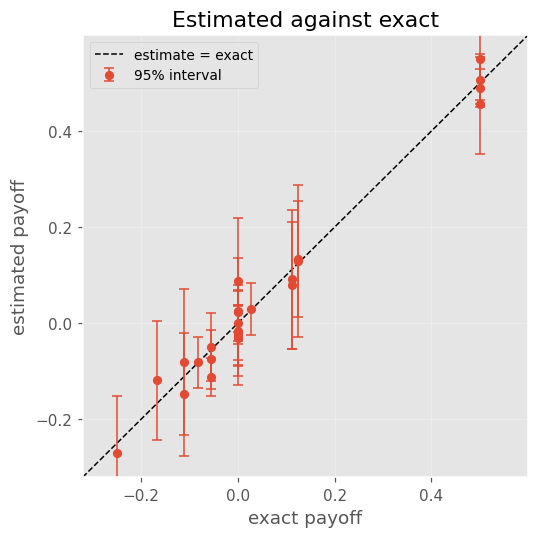

In [11]:
meta = EmpiricalMetaGame(game, episodes_per_seed=META_EPISODES,
                         num_seeds=META_SEEDS, base_seed=SEED)
for policy in baselines0:
    meta.add_policy(0, policy)
for policy in baselines1:
    meta.add_policy(1, policy)

filled = meta.update()
print(f'Evaluated {filled} entries, {meta.episodes_simulated:,} episodes in total')

estimated = meta.matrix
low, high = meta.confidence_interval(CONFIDENCE)
inside = (baseline_matrix >= low) & (baseline_matrix <= high)

print('Estimated payoff matrix:')
display(pd.DataFrame(estimated, index=names, columns=names).round(4))
print('Standard error:')
display(pd.DataFrame(meta.standard_error, index=names, columns=names).round(4))
print('Absolute error against the exact matrix:')
display(pd.DataFrame(np.abs(estimated - baseline_matrix),
                     index=names, columns=names).round(4))

print(f'Largest error: {np.abs(estimated - baseline_matrix).max():.4f}')
print(f'Exact value inside the {CONFIDENCE:.0%} interval: '
      f'{inside.sum()} of {inside.size} entries')

fig, ax = plt.subplots(figsize=(5, 5))
lim = [min(baseline_matrix.min(), estimated.min()) - 0.05,
       max(baseline_matrix.max(), estimated.max()) + 0.05]
ax.plot(lim, lim, color='black', linestyle='--', linewidth=1, label='estimate = exact')
ax.errorbar(baseline_matrix.ravel(), estimated.ravel(),
            yerr=(high - estimated).ravel(), fmt='o', markersize=5,
            capsize=3, linewidth=1, label=f'{CONFIDENCE:.0%} interval')
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel('exact payoff')
ax.set_ylabel('estimated payoff')
ax.set_title('Estimated against exact')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח האומד:</p>
<ul>
<li>24 מתוך 25 המשבצות מכילות את המדויק ברווח הסמך — 96 אחוזים מול 95. הרווח נבנה עם מכפיל t ולא 1.96</li>
<li>הנקודות בגרף נופלות משני צדי הישר בלי הטיה שיטתית: האומד חסר הטיה, והשגיאה היא רעש ולא סטייה</li>
<li>אבל השגיאה הגדולה, 0.0875, עולה על הפער בין הפותרים המובילים בניסוי 2 (0.028 מול 0.032) — ומכאן חמישה seeds ורווחי סמך</li>
<li>שגיאת התקן משתנה פי ארבעה בין משבצות (0.013 עד 0.057): צמדים שהתגמול ביניהם תנודתי יותר דורשים יותר אפיזודות לאותו דיוק</li>
<li>50,000 אפיזודות ל-25 משבצות, 2,000 לכל אחת. בזכות הדגימה מהתפלגות התגמול המדויקת זה עולה שברירי שנייה במקום דקות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>המצטבריות: מוסיפים מדיניות ורק השורה החדשה מחושבת. ההתכנסות: פי 4 אפיזודות חוצה את שגיאת התקן — קצב שורש הדגימות.</p>
</div>

New entries evaluated : 5 (expected 5, the size of the new row)
Existing entries unchanged: True
Additional episodes   : 10,000


,episodes per entry,largest error,mean standard error
0,250,0.1438,0.0793
1,1000,0.1230,0.0405
2,4000,0.0526,0.0212
3,16000,0.0340,0.0092


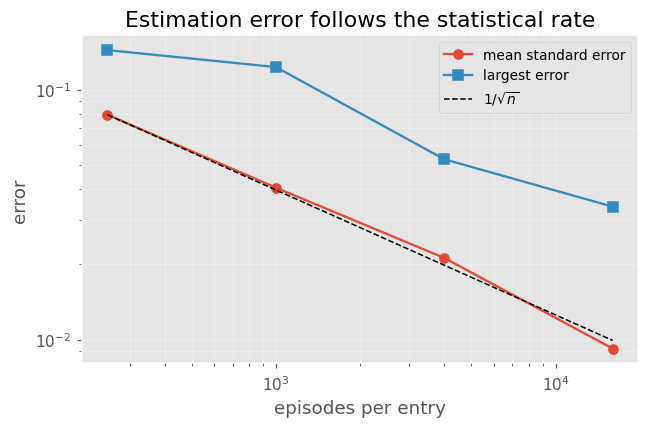

In [12]:
before = {key: value.copy() for key, value in meta._seed_means.items()}
episodes_before = meta.episodes_simulated

meta.add_policy(0, kuhn_nash_policies(0.0)[0])
new_entries = meta.update()

print(f'New entries evaluated : {new_entries} (expected {len(baselines1)}, '
      f'the size of the new row)')
print('Existing entries unchanged:',
      all(np.array_equal(v, meta._seed_means[k]) for k, v in before.items()))
print(f'Additional episodes   : {meta.episodes_simulated - episodes_before:,}')

rows = []
for episodes in CONVERGENCE_EPISODES:
    probe = EmpiricalMetaGame(game, episodes_per_seed=episodes,
                              num_seeds=META_SEEDS, base_seed=SEED + 1)
    for policy in baselines0:
        probe.add_policy(0, policy)
    for policy in baselines1:
        probe.add_policy(1, policy)
    probe.update()
    rows.append({'episodes per entry': episodes * META_SEEDS,
                 'largest error': round(float(np.abs(probe.matrix - baseline_matrix).max()), 4),
                 'mean standard error': round(float(probe.standard_error.mean()), 4)})
convergence_table = pd.DataFrame(rows)
display(convergence_table)

n = convergence_table['episodes per entry'].values

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n, convergence_table['mean standard error'],
          marker='o', label='mean standard error')
ax.loglog(n, convergence_table['largest error'],
          marker='s', label='largest error')
ax.loglog(n, convergence_table['mean standard error'].iloc[0] * np.sqrt(n[0] / n),
          color='black', linestyle='--', linewidth=1, label=r'$1/\sqrt{n}$')
ax.set_xlabel('episodes per entry')
ax.set_ylabel('error')
ax.set_title('Estimation error follows the statistical rate')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח המצטבריות וההתכנסות:</p>
<ul>
<li>הוספת מדיניות חישבה 5 משבצות ולא 30, והקיימים נשארו זהים. PSRO כדאי חישובית כי באיטרציה t מתווספות כ-2t משבצות במקום t בריבוע</li>
<li>שגיאת התקן יושבת על הישר של 1/√n ונחצית בכל הכפלה פי 4 באפיזודות (0.079, 0.041, 0.021, 0.009) — קצב שורש, כצפוי מאומד ממוצע</li>
<li>השגיאה המרבית יורדת לאט יותר, וזה צפוי: היא מקסימום על 25 משבצות ולא ממוצע</li>
<li>פי 64 אפיזודות קנו רק פי 4.2 בשגיאה המרבית — תשואה פוחתת שבגללה עוצרים על 2,000 למשבצת, ומכאן עוצמת אבלציית ההערכה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>5. ה-Response Oracle (חלק ג' במפרט)</p>
<p>ה-oracle מאמן תגובה מיטבית מקורבת מול המטא-אסטרטגיה היריבה. כמתחייב מהמפרט, בכל אפיזודה מוגרלת מדיניות אחת הקבועה לאורכה.</p>
<ul>
<li>שלושה מימושים: Q-learning טבלאי, REINFORCE עם baseline, ותגובה מיטבית מדויקת במניית אסטרטגיות</li>
<li>הכול נכתב מאפס ללא ספריית RL — עדכון ה-Q, תזמון האפסילון, אומד הגרדיאנט ולולאת האפיזודות</li>
<li>בקצב למידה קבוע התגלתה הרעבת חקירה: check עם ג'ק שווה 1- ודאי, ואילו bet שווה 0.5- אך משלם 2- או 1+ באקראי</li>
<li>רצף ביש-מזל מפיל את האומד הרועש מתחת לדטרמיניסטי, החמדן נוטש והחקירה מתמוטטת. קצב מבוסס ספירות סגר את הפער</li>
<li>ה-oracle המדויק אינו למידה אלא גבול ה-oracle המושלם, ומשמש כאמת מידה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>שני האורקלים המקורבים מול חמש קבוצות יריבים ובשני תקציבים, מושווים לתגובה המיטבית המדויקת. הטבלה השנייה היא הפער מהאופטימום.</p>
</div>

In [13]:
opponent_sets = {
    'random': ([RandomPolicy()], [1.0]),
    'tight': ([kuhn_heuristic(1)], [1.0]),
    'aggro': ([kuhn_always_bet(1)], [1.0]),
    'nash': ([nash1], [1.0]),
    'mixture': ([RandomPolicy(), kuhn_heuristic(1), nash1], [0.5, 0.3, 0.2]),
}

def achieved_value(policy, opponents, weights):
    return sum(w * exact_value(game, policy, o)
               for o, w in zip(opponents, weights))

rows = []
for label, (opponents, weights) in opponent_sets.items():
    optimal = ExactBestResponse(game, 0).best_response_value(opponents, weights)
    row = {'opponent': label, 'exact BR': round(optimal, 4)}
    for name, oracle in [('Q-learning', TabularQLearningOracle()),
                         ('REINFORCE', ReinforceOracle(learning_rate=REINFORCE_LR))]:
        for budget in ORACLE_DEMO_BUDGETS:
            achieved = achieved_value(
                oracle.train(game, 0, opponents, weights, budget, seed=SEED).policy,
                opponents, weights)
            row[f'{name} {budget // 1000}k'] = round(achieved, 4)
            row[f'gap {name} {budget // 1000}k'] = round(optimal - achieved, 4)
    rows.append(row)
oracle_table = pd.DataFrame(rows)
display(oracle_table[[c for c in oracle_table.columns if not c.startswith('gap')]])
print('Gap from the exact best response (lower is better):')
display(oracle_table[['opponent'] + [c for c in oracle_table.columns
                                     if c.startswith('gap')]])

,opponent,exact BR,Q-learning 2k,Q-learning 20k,REINFORCE 2k,REINFORCE 20k
0,random,0.5000,0.5000,0.5000,0.4930,0.4996
1,tight,0.1667,0.1667,0.1667,0.1535,0.1659
2,aggro,0.3333,0.3333,0.3333,0.3250,0.3319
3,nash,-0.0556,-0.0556,-0.0556,-0.0615,-0.0558
4,mixture,0.2278,0.2278,0.2278,0.2211,0.2274


Gap from the exact best response (lower is better):


,opponent,gap Q-learning 2k,gap Q-learning 20k,gap REINFORCE 2k,gap REINFORCE 20k
0,random,0.0,0.0,0.0070,0.0004
1,tight,0.0,0.0,0.0132,0.0007
2,aggro,0.0,0.0,0.0084,0.0014
3,nash,0.0,0.0,0.0060,0.0002
4,mixture,0.0,0.0,0.0067,0.0004


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח האורקלים:</p>
<ul>
<li>Q-learning מגיע לתגובה המיטבית המדויקת בכל עשרת המקרים, פער 0.0 בדיוק — וכבר ב-2,000 אפיזודות</li>
<li>הסיבה מבנית: מול יריב קבוע התגובה המיטבית דטרמיניסטית, והחמדן שנגזר מ-Q מוצא אותה. זה מה שהקצב מבוסס הספירות הבטיח</li>
<li>REINFORCE אינו מגיע לאפס — הוא מייצר softmax. הפער יורד מ-0.013 ל-0.0007 עם פי עשרה תקציב, והוא בפרויקט כי שיווי המשקל מעורב</li>
<li>מול שיווי המשקל שניהם מקבלים 1/18- ולא יותר, כמתחייב תיאורטית. זו בדיקת שפיות: oracle שהיה מנצח את שיווי המשקל היה מעיד על באג</li>
<li>שורת mixture היא המקרה שבאמת נחשב — ב-PSRO ה-oracle תמיד מתאמן מול תערובת ולא יריב יחיד. גם שם Q-learning מדויק לחלוטין</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>6. פותרי המטא-אסטרטגיה (חלק ד' במפרט)</p>
<p>הפותר קורא את המטריצה ומחזיר התפלגות מעל אוכלוסיית כל שחקן. ה-oracle מתאמן מולה, והיא שהופכת את PSRO למשפחת אלגוריתמים.</p>
<ul>
<li>המפרט דורש שלושה פותרים ואחד סטוכסטי לא אחיד; כאן מומשו כל השבעה, ובנוסף rectified Nash מהספרות</li>
<li>בחירת הפותר היא בחירת האלגוריתם: self_play נותן self-play, nash נותן double oracle, uniform נותן משהו דמוי fictitious play</li>
<li>אימות במשחקים שפתרונם ידוע: אבן-נייר-ומספריים, matching pennies, אסטרטגיה שולטת, ולא-טרנזיטיבי אסימטרי עם שיווי משקל משוקלל</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>פתרון נאש על ארבעה משחקים שפתרונם ידוע, מול המצופה. שמונת הפותרים באבן-נייר-ומספריים — הפלט והאנטרופיה שלהם, בטבלה ובגרף.</p>
</div>

,game,sigma0,value,expected
0,rock-paper-scissors,"[0.3333, 0.3333, 0.3333]",-0.0,"uniform, value 0"
1,matching pennies,"[0.5, 0.5]",-0.0,"uniform, value 0"
2,dominant strategy,"[0.0, 1.0]",1.0,"pure on row 2, value 1"
3,asymmetric non-transitive,"[0.3333, 0.5, 0.1667]",-0.0,"weighted, value 0"


,solver,sigma0,entropy
0,uniform,"[0.3333, 0.3333, 0.3333]",1.0986
1,self_play,"[0.0, 0.0, 1.0]",-0.0000
2,fictitious_play,"[0.3263, 0.3348, 0.3388]",1.0985
3,nash,"[0.3333, 0.3333, 0.3333]",1.0986
4,replicator,"[0.3333, 0.3333, 0.3333]",1.0986
5,projected_replicator,"[0.3333, 0.3333, 0.3333]",1.0986
6,regret_matching,"[0.3333, 0.3333, 0.3333]",1.0986
7,rectified_nash,"[0.5, 0.0, 0.5]",0.6931


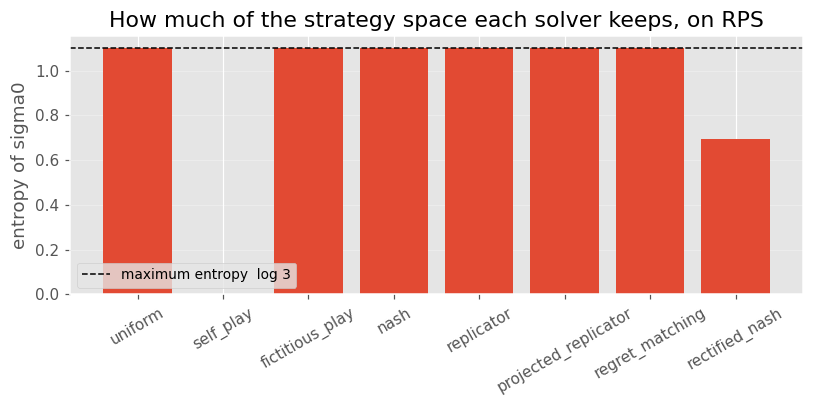

In [14]:
RPS = np.array([[0., -1, 1], [1, 0, -1], [-1, 1, 0]])
PENNIES = np.array([[1., -1], [-1, 1]])
DOMINANCE = np.array([[3., 0.], [5., 1.]])
ASYMMETRIC = np.array([[0., -1, 3], [1, 0, -2], [-3, 2, 0]])

rows = []
for label, matrix, expected in [
    ('rock-paper-scissors', RPS, 'uniform, value 0'),
    ('matching pennies', PENNIES, 'uniform, value 0'),
    ('dominant strategy', DOMINANCE, 'pure on row 2, value 1'),
    ('asymmetric non-transitive', ASYMMETRIC, 'weighted, value 0'),
]:
    sigma0, sigma1, value = solve_zero_sum_nash(matrix)
    rows.append({'game': label, 'sigma0': np.round(sigma0, 4),
                 'value': round(value, 6), 'expected': expected})
display(pd.DataFrame(rows))

rows = []
for name, solver in SOLVERS.items():
    sigma0, _sigma1 = solver(RPS)
    rows.append({'solver': name, 'sigma0': np.round(sigma0, 4),
                 'entropy': round(strategy_entropy(sigma0), 4)})
solver_table = pd.DataFrame(rows)
display(solver_table)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.bar(solver_table['solver'], solver_table['entropy'])
ax.axhline(np.log(3), color='black', linestyle='--', linewidth=1,
           label='maximum entropy  log 3')
ax.set_ylabel('entropy of sigma0')
ax.set_title('How much of the strategy space each solver keeps, on RPS')
ax.tick_params(axis='x', rotation=30)
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח הפותרים:</p>
<ul>
<li>הפותר נכון בארבעת המשחקים, והרביעי בודק אותו: רק שם שיווי המשקל משוקלל — (1/3, 1/2, 1/6). מימוש שמחזיר אחיד עובר שלוש מארבע</li>
<li>במשחק עם אסטרטגיה שולטת התקבל פתרון טהור ולא מעורב: הפותר אינו כופה ערבוב כשאין בו צורך</li>
<li>self_play מרכז את כל המסה על המדיניות האחרונה, ולכן האנטרופיה שלו אפס. זו ההתנהגות שהופכת אותו לקבוצת הביקורת של הפרויקט</li>
<li>rectified_nash נשאר עם log 2 במקום log 3 — הוריד את Paper. כבר כאן זורק שליש מהמרחב, כפי שיקרה בניסוי 2</li>
<li>fictitious_play ב-1.0985 ולא 1.0986: מתכנס לאחיד בלי להגיע, כי המטא-אסטרטגיה שלו תדירות אמפירית אחרי מספר סופי של איטרציות</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>7. ריצת PSRO אחת מלאה (חלק ה' במפרט)</p>
<p>ריצת PSRO שלמה וניתנת לשחזור, כמבוקש במפרט. כל איטרציה — השלמת החסר, פתירת המטא-משחק, תגובה מיטבית לכל שחקן, ומדידה.</p>
<ul>
<li>ה-exploitability מחושב בכל איטרציה על המטריצה המדויקת ולא הנאמדת, כדי שהמדד לא יזוהם ברעש הדגימה</li>
<li>כל מדיניות, מטריצה ומטא-אסטרטגיה נשמרות, כך שריצה שנקטעה נמשכת</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>12 איטרציות עם nash כפותר ו-Q-learning כאורקל, מאוכלוסייה אקראית. סיכום: האוכלוסייה, ה-exploitability, הערך, התמיכה ותקציב האפיזודות.</p>
</div>

In [15]:
config = PSROConfig(meta_solver=DEMO_SOLVER, oracle='q_learning',
                    iterations=DEMO_ITERATIONS, oracle_budget=DEMO_ORACLE_BUDGET,
                    episodes_per_seed=DEMO_EPISODES, num_seeds=DEMO_SEEDS, seed=SEED)

demo = PSRO(game, config, ([RandomPolicy('random')], [RandomPolicy('random')]))
demo.run(verbose=True)
report = demo.final_report()

print()
print(f'Final population size   : {report["population_sizes"][0]}')
print(f'Final exploitability    : {report["final_exploitability"]:.4f}')
print(f'Game value reached      : {report["exact_value"]:+.4f} '
      f'(analytic {KUHN_GAME_VALUE:+.4f})')
print(f'Policies in the support : {len(report["support0"])} of '
      f'{report["population_sizes"][0]}')
print(f'Meta-strategy entropy   : {report["entropy0"]:.4f}')
print(f'Evaluation episodes     : {report["total_evaluation_episodes"]:,}')
print(f'Oracle episodes         : {report["total_oracle_episodes"]:,}')

PSRO on kuhn_poker: solver=nash, oracle=q_learning, budget=5,000, seed=0
  it   0  |Pi|=  2  expl=  0.9167  H(sigma0)=-0.000  V=+0.1295    0.6s
  it   1  |Pi|=  3  expl=  0.8333  H(sigma0)=-0.000  V=-0.2185    0.5s
  it   2  |Pi|=  4  expl=  0.3333  H(sigma0)=-0.000  V=-0.1160    0.8s
  it   3  |Pi|=  5  expl=  0.2828  H(sigma0)=0.854  V=+0.0427    0.7s
  it   4  |Pi|=  6  expl=  0.1424  H(sigma0)=0.952  V=+0.0025    0.7s
  it   5  |Pi|=  7  expl=  0.0891  H(sigma0)=1.070  V=-0.0355    0.7s
  it   6  |Pi|=  8  expl=  0.0891  H(sigma0)=1.070  V=-0.0355    0.7s
  it   7  |Pi|=  9  expl=  0.0891  H(sigma0)=1.070  V=-0.0355    0.7s
  it   8  |Pi|= 10  expl=  0.0623  H(sigma0)=1.008  V=-0.0516    0.7s
  it   9  |Pi|= 11  expl=  0.0406  H(sigma0)=0.991  V=-0.0482    0.7s
  it  10  |Pi|= 12  expl=  0.0207  H(sigma0)=1.090  V=-0.0469    0.7s
  it  11  |Pi|= 13  expl=  0.0203  H(sigma0)=1.342  V=-0.0473    0.6s

Final population size   : 13
Final exploitability    : 0.0229
Game value reached   

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח בלוק הסיכום:</p>
<ul>
<li>ערך המשחק נוחת על 0.0561- מול 0.0556- האנליטי, פער של 0.0005, אף שהתערובת נפתרה על מטריצה מוערכת ולא מדויקת</li>
<li>4 מדיניות מתוך 13 בתמיכה, ואנטרופיה 1.0160 שהיא כ-2.8 במשקל שווה. התשע אילוצים בתוכנית הליניארית, שהפתרון לא מפסיד מולן</li>
<li>ההערכה יקרה מהלמידה: 338,000 אפיזודות מול 120,000 באורקל, והן 169 משבצות, 13 בריבוע, כפול 2,000 — מול 819 בחישוב מחדש</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מציג את היסטוריית הריצה כטבלה, ולצדה שלושה גרפים: ירידת ה-exploitability בסולם לוגריתמי, עליית אנטרופיית המטא-אסטרטגיה, וחלוקת תקציב האפיזודות. הנקודה הפתוחה בסופו היא הפתרון מחדש, שמעריך ואינו מאמן.</p>
</div>

,iteration,population,exploitability,entropy,exact value,estimated value,eval episodes,oracle episodes,seconds
0,1,2,0.9167,-0.0000,0.1250,0.1295,2000,10000,0.5638
1,2,3,0.8333,-0.0000,-0.1667,-0.2185,8000,20000,0.5241
2,3,4,0.3333,-0.0000,-0.0833,-0.1160,18000,30000,0.7521
3,4,5,0.2828,0.8537,0.0620,0.0427,32000,40000,0.6910
4,5,6,0.1424,0.9516,-0.0109,0.0025,50000,50000,0.6717
5,6,7,0.0891,1.0702,-0.0428,-0.0355,72000,60000,0.6825
6,7,8,0.0891,1.0702,-0.0428,-0.0355,98000,70000,0.6723
7,8,9,0.0891,1.0702,-0.0428,-0.0355,128000,80000,0.6777
8,9,10,0.0623,1.0083,-0.0571,-0.0516,162000,90000,0.6992
9,10,11,0.0406,0.9906,-0.0568,-0.0482,200000,100000,0.7168


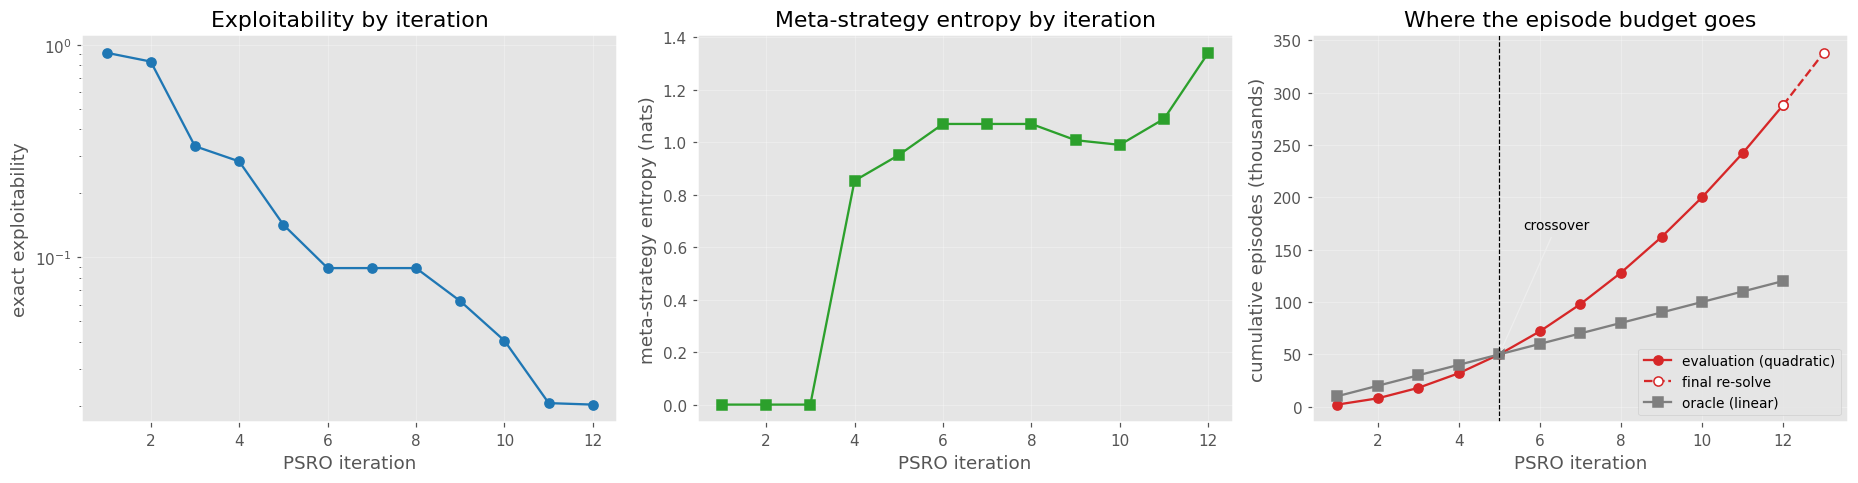

In [16]:
frame = demo.history_frame()
demo_table = frame[['iteration', 'population0', 'exploitability', 'entropy0',
                    'exact_value', 'empirical_value', 'evaluation_episodes',
                    'wall_seconds']].copy()
demo_table['iteration'] += 1
demo_table.insert(7, 'oracle_episodes',
                  2 * DEMO_ORACLE_BUDGET * demo_table['iteration'])
demo_table.columns = ['iteration', 'population', 'exploitability', 'entropy',
                      'exact value', 'estimated value', 'eval episodes',
                      'oracle episodes', 'seconds']
display(demo_table.round(4))

figure, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].plot(demo_table['iteration'], demo_table['exploitability'],
             marker='o', color='#1f77b4')
axes[0].set_yscale('log')
axes[0].set_xlabel('PSRO iteration')
axes[0].set_ylabel('exact exploitability')
axes[0].set_title('Exploitability by iteration')
axes[0].grid(alpha=0.3)

axes[1].plot(demo_table['iteration'], demo_table['entropy'],
             marker='s', color='#2ca02c')
axes[1].set_xlabel('PSRO iteration')
axes[1].set_ylabel('meta-strategy entropy (nats)')
axes[1].set_title('Meta-strategy entropy by iteration')
axes[1].grid(alpha=0.3)

final_iteration = int(demo_table['iteration'].iloc[-1]) + 1
axes[2].plot(demo_table['iteration'], demo_table['eval episodes'] / 1000,
             marker='o', color='#d62728', label='evaluation (quadratic)')
axes[2].plot([demo_table['iteration'].iloc[-1], final_iteration],
             [demo_table['eval episodes'].iloc[-1] / 1000,
              report['total_evaluation_episodes'] / 1000],
             marker='o', markerfacecolor='white', linestyle='--',
             color='#d62728', label='final re-solve')
axes[2].plot(demo_table['iteration'], demo_table['oracle episodes'] / 1000,
             marker='s', color='#7f7f7f', label='oracle (linear)')
axes[2].axvline(5, color='black', linewidth=0.8, linestyle='--')
axes[2].annotate('crossover', xy=(5, 50), xytext=(5.6, 170), fontsize=9,
                 arrowprops=dict(arrowstyle='->', linewidth=0.8))
axes[2].set_xlabel('PSRO iteration')
axes[2].set_ylabel('cumulative episodes (thousands)')
axes[2].set_title('Where the episode budget goes')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח הריצה המלאה:</p>
<ul>
<li>ה-exploitability יורד פי 45, מ-0.9167 ל-0.0203. הפתיחה היא 11/12 בדיוק, הקבוע שבו OpenSpiel בודק את עצמו — נקודת מוצא מאומתת</li>
<li>איטרציות 6 עד 8 זהות ב-exploitability (0.0891), באנטרופיה ובערך, והאוכלוסייה גדלה מ-7 ל-9: שתי המדיניות שנוספו קיבלו משקל אפס</li>
<li>האנטרופיה אפס בשלוש הראשונות, קופצת ל-0.8537 ברביעית ומסיימת ב-1.3417. זה מבדיל את PSRO מ-self-play, שבו היא אפס לנצח</li>
<li>הפער בין המדויק לנאמד מצטמצם מ-0.05 לפחות מ-0.01 מאיטרציה 6: תערובת טהורה היא משבצת בודדת עם שגיאתה, ורחבה ממצעת</li>
<li>השורה האחרונה: 0.0203 ו-0.0556-, הסיכום 0.0229 ו-0.0561-. המדדים קודמים להוספה, ולכן היא של 12 מדיניות והסיכום של 13, שהחמירה</li>
<li>ההערכה היא 2,000 כפול ריבוע האיטרציה והאורקל 10,000 כפולה — ריבועי מול לינארי, שנחתכים באיטרציה 5. משם הפער נפתח בלי גבול</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא בודק את דרישת השחזור מהמפרט: שומרים את הריצה, טוענים מחדש, ומוודאים שהמטריצה זהה ושאין משבצת לחישוב. התיקייה נמחקת.</p>
</div>

In [17]:
checkpoint_dir = os.path.join(PATH, 'checkpoint_demo')
demo.save(checkpoint_dir)
restored = PSRO.load(checkpoint_dir, game)

print('Iteration restored     :', restored.iteration)
print('Population sizes       :', [len(pop) for pop in restored.populations])
print('Payoff matrix identical:',
      np.allclose(restored.metagame.matrix, demo.metagame.matrix))
print('Nothing left to simulate:', restored.metagame.update() == 0)
print('Files written          :', sorted(os.listdir(checkpoint_dir)))

shutil.rmtree(checkpoint_dir, ignore_errors=True)

Iteration restored     : 12
Population sizes       : [13, 13]
Payoff matrix identical: True
Nothing left to simulate: True
Files written          : ['checkpoint.json', 'payoff_matrix.json']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח בדיקת השחזור: הריצה חזרה באותה איטרציה ואוכלוסייה, ומטריצת התגמולים זהה עד לדיוק מספרי. לא נותרה אף משבצת לחישוב: גם המצב הפנימי של האומד שוחזר ולא רק המדיניות — והמשך עולה אפס אפיזודות במקום 338,000. שני קובצי JSON מחזיקים את הכל, כדרישת המפרט.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>8. גבול ההתכנסות התיאורטי — double oracle עם חישוב מדויק לחלוטין</p>
<p>ל-double oracle יש ערובת התכנסות (McMahan, Gordon ו-Blum, 2003): במשחק סופי הוא מסתיים במספר סופי של איטרציות בשיווי משקל של המשחק המלא, לא רק של תת-המשחק שנבנה. PSRO עם פותר נאש הוא בדיוק האלגוריתם הזה.</p>
<p>עד כה ה-exploitability נעצר סביב 0.02 ולא הגיע לאפס — מגבלה של האלגוריתם או של המדידה? התא הבא מריץ את אותה לולאה עם oracle מדויק ומטריצה מדויקת, בלי דגימה בשום מקום.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ double oracle טהור, ובודק לכל שחקן בנפרד אם האורקל ייצר מדיניות חדשה — תנאי העצירה של המשפט הוא ששניהם חדלו. שני הגרפים הם אותה ריצה: הלינארי למסלול, הלוגריתמי לסדר הגודל של הנפילה.</p>
</div>

,iteration,population,exploitability,game value,P0 found new,P1 found new
0,1,1,9.166667e-01,0.125000,True,True
1,2,2,8.333333e-01,-0.166667,True,True
2,3,3,3.333333e-01,0.000000,True,True
3,4,4,1.833333e-01,0.033333,True,True
4,5,5,2.222222e-01,0.013889,True,True
5,6,6,1.354167e-01,-0.052083,True,True
6,7,7,4.163336e-17,-0.055556,True,False


Terminated after 7 iterations with a population of 7
Final exploitability : 4.163e-17
Game value reached   : -0.05555556 (analytic -0.05555556)


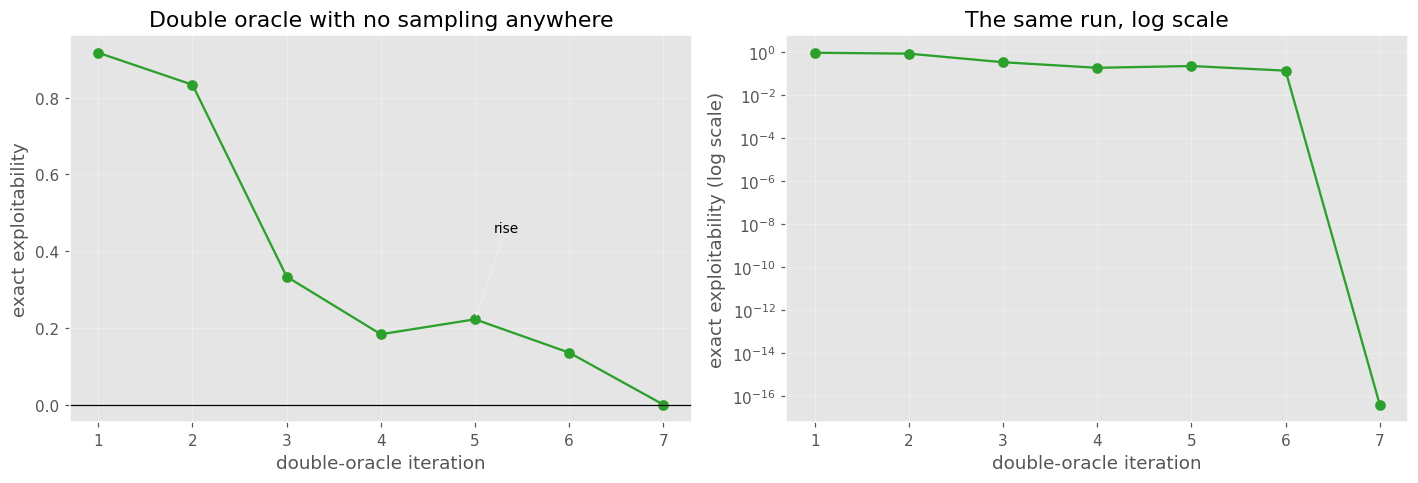

In [18]:
br_exact0 = ExactBestResponse(game, 0)
br_exact1 = ExactBestResponse(game, 1)
exact_oracle = ExactOracle()

pop0, pop1 = [RandomPolicy('r0')], [RandomPolicy('r1')]
seen0, seen1 = set(), set()
rows = []

def signature(policy, player):
    return tuple(round(v, 9) for v in policy.bet_probabilities(game, player).values())

for iteration in range(1, MAX_EXACT_ITERATIONS + 1):
    matrix = exact_payoff_matrix(game, pop0, pop1)
    sigma0, sigma1 = SOLVERS['nash'](matrix)
    measured = exploitability(game, pop0, sigma0, pop1, sigma1,
                              br_exact0, br_exact1, matrix)

    new0 = exact_oracle.train(game, 0, pop1, sigma1, 0, 0).policy
    new1 = exact_oracle.train(game, 1, pop0, sigma0, 0, 0).policy
    fresh0 = signature(new0, 0) not in seen0
    fresh1 = signature(new1, 1) not in seen1

    rows.append({'iteration': iteration,
                 'population': len(pop0),
                 'exploitability': measured['exploitability'],
                 'game value': measured['value0'],
                 'P0 found new': fresh0,
                 'P1 found new': fresh1})
    if measured['exploitability'] < 1e-12 or not (fresh0 or fresh1):
        break
    seen0.add(signature(new0, 0))
    seen1.add(signature(new1, 1))
    pop0.append(new0)
    pop1.append(new1)

exact_trace = pd.DataFrame(rows)
display(exact_trace)

final = exact_trace.iloc[-1]
print(f'Terminated after {int(final["iteration"])} iterations '
      f'with a population of {int(final["population"])}')
print(f'Final exploitability : {final["exploitability"]:.3e}')
print(f'Game value reached   : {final["game value"]:+.8f} '
      f'(analytic {KUHN_GAME_VALUE:+.8f})')

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(exact_trace['iteration'], exact_trace['exploitability'],
             marker='o', color='#2ca02c')
axes[0].axhline(0.0, color='black', linewidth=0.8)
axes[0].annotate('rise', xy=(5, 0.2222), xytext=(5.2, 0.45), fontsize=9,
                 arrowprops=dict(arrowstyle='->', linewidth=0.8))
axes[0].set_xlabel('double-oracle iteration')
axes[0].set_ylabel('exact exploitability')
axes[0].set_title('Double oracle with no sampling anywhere')
axes[0].grid(alpha=0.3)

axes[1].semilogy(exact_trace['iteration'],
                 np.maximum(exact_trace['exploitability'], 1e-17),
                 marker='o', color='#2ca02c')
axes[1].set_xlabel('double-oracle iteration')
axes[1].set_ylabel('exact exploitability (log scale)')
axes[1].set_title('The same run, log scale')
axes[1].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח גבול ההתכנסות:</p>
<ul>
<li>שבע איטרציות, אוכלוסייה של שבע, ו-exploitability של 4.163e-17 — אפס של מכונה. משפט ההתכנסות של double oracle מאומת ישירות</li>
<li>ערך המשחק יוצא 0.05555556-, זהה לערך האנליטי עד הספרה האחרונה</li>
<li>העקומה אינה מונוטונית: 0.1833 באיטרציה 4 ו-0.2222 בחמישית. הוספת מדיניות משנה את כל המטא-משחק ולכן יכולה להרע זמנית</li>
<li>שחקן 1 חדל למצוא תגובות חדשות באיטרציה 7, שחקן 0 לא: בשיווי משקל התגובות המיטביות אינן יחידות, ולכן ה-exploitability הוא שעוצר</li>
<li>שבע מדיניות לאפס מדויק כאן, מול 13 שנתקעו על 0.0229 בסעיף 7. הפער שם אינו שגיאת אלגוריתם אלא הרעש במטריצה וקירוב האורקל</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>8.1 תעודת ההתכנסות: הפער שהאלגוריתם עצמו משתמש בו כתנאי עצירה</p>
<p>ה-exploitability מדרג את תערובת הפותר, ולכן כל פותר נבחן לפי עצמו. Wang, Ma ו-Wellman (AAMAS 2022): קריטריון העקביות, שרבים מפרים.</p>
<p>החלופה: לדרג את האוכלוסייה, ה-exploitability של התערובת הטובה ביותר שהיא מסוגלת לבטא — population exploitability, שאינו תלוי בפותר.</p>
<p>זול לחישוב: ה-exploitability סכום שני ערכי תגובה מיטבית, וכל חצי ממוזער בנפרד — שתי תוכניות לינאריות בין אוכלוסייה למרחב המלא של השני.</p>
<p>החצאים חסם עליון ותחתון על ערך המשחק, וההפרש הוא הפער ש-double oracle עוצר עליו. אפס אינו קירוב להתכנסות — הוא תעודת ההתכנסות.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ את ה-double oracle ומדווח את החסמים והפער. התגובות המיטביות מחושבות מול האוכלוסיות בתחילת האיטרציה, ומכאן ה-[:-1].</p>
</div>

,iteration,population,upper bound on value,lower bound on value,population exploitability
0,0,1,0.500000,-0.416667,9.166667e-01
1,1,2,0.250000,-0.333333,5.833333e-01
2,2,3,0.166667,-0.166667,3.333333e-01
3,3,4,0.083333,-0.064103,1.474359e-01
4,4,5,0.055556,-0.064103,1.196581e-01
5,5,6,-0.027778,-0.064103,3.632479e-02
6,6,7,-0.055556,-0.055556,4.163336e-17


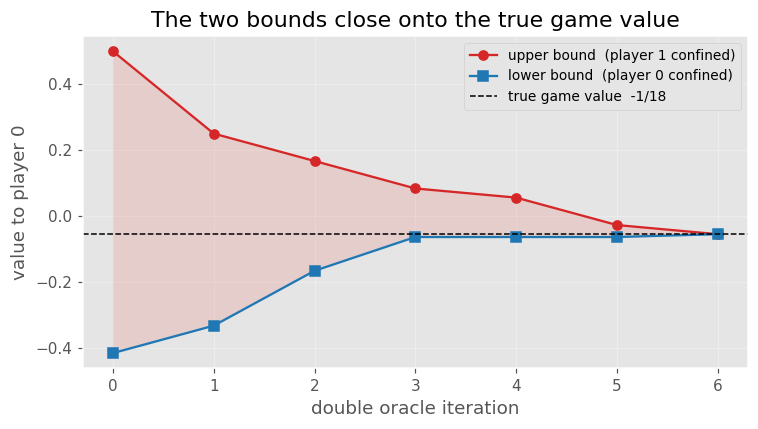

Final gap  : 4.16e-17
Iterations : 6
True value : -0.0555555556


In [19]:
pop0_gap, pop1_gap = [RandomPolicy('r0')], [RandomPolicy('r1')]
rows = []
for iteration in range(0, MAX_EXACT_ITERATIONS + 1):
    if iteration:
        matrix = exact_payoff_matrix(game, pop0_gap, pop1_gap)
        sigma0, sigma1 = SOLVERS['nash'](matrix)
        pop0_gap = pop0_gap + [exact_oracle.train(game, 0, pop1_gap, sigma1, 0, 0).policy]
        pop1_gap = pop1_gap + [exact_oracle.train(game, 1, pop0_gap[:-1], sigma0, 0, 0).policy]
    bounds = population_exploitability(game, pop0_gap, pop1_gap)
    rows.append({
        'iteration': iteration,
        'population': len(pop0_gap),
        'upper bound on value': round(bounds['value_upper'], 8),
        'lower bound on value': round(bounds['value_lower'], 8),
        'population exploitability': bounds['population_exploitability'],
    })
    if bounds['population_exploitability'] < 1e-9:
        break

gap_table = pd.DataFrame(rows)
display(gap_table)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gap_table['iteration'], gap_table['upper bound on value'],
        marker='o', color='#d62728', label='upper bound  (player 1 confined)')
ax.plot(gap_table['iteration'], gap_table['lower bound on value'],
        marker='s', color='#1f77b4', label='lower bound  (player 0 confined)')
ax.axhline(KUHN_GAME_VALUE, color='black', linestyle='--', linewidth=1,
           label='true game value  -1/18')
ax.fill_between(gap_table['iteration'], gap_table['lower bound on value'],
                gap_table['upper bound on value'], alpha=0.15)
ax.set_xlabel('double oracle iteration')
ax.set_ylabel('value to player 0')
ax.set_title('The two bounds close onto the true game value')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Final gap  : {gap_table["population exploitability"].iloc[-1]:.2e}')
print(f'Iterations : {int(gap_table["iteration"].iloc[-1])}')
print(f'True value : {KUHN_GAME_VALUE:.10f}')

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קריאת התעודה:</p>
<ul>
<li>החסמים מקיפים את הערך האמיתי 1/18-, והשטח המוצל הוא הפער. סגירתו לאפס: האוכלוסייה מכילה תמיכה של שיווי משקל במשחק המלא</li>
<li>הפער יורד בכל צעד, בעוד ה-exploitability בתא הקודם עלה באיטרציה 5. מינימום מעל קבוצה גדֵלה רק קטן, בניגוד לתערובת אחת</li>
<li>החסם התחתון במרחק 0.0085 כבר באיטרציה 3 ושטוח שלוש איטרציות, בעוד לעליון נותר 0.14 לעבור. שניהם נוחתים יחד באיטרציה 6</li>
<li>הפער מגיע לדיוק מכונה ולא רק מתקרב לאפס. המשפט של McMahan אינו טוען שהפער שואף לאפס אלא שהאלגוריתם עוצר בזמן סופי</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>9. ראיות התנהגותיות — מה המדיניות שנלמדה עושה בפועל (סעיף 12 במפרט)</p>
<p>המפרט דורש ראיות התנהגותיות: נמדדו exploitability ואנטרופיה, לא מה הפתרון משחק. לתערובת אין טבלת אסטרטגיה, אבל יש התנהגות בשולחן.</p>
<p>ל-Kuhn משפחת שיווי משקל, שאיבריה נבדלים בהתנהגות. השוואה לאיבר שרירותי תיראה כסטייה גם במושלמת — קודם מזהים אותו.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ 40,000 ידיים מול שיווי המשקל. שלוש קבוצות מידע נותנות הערכות בלתי תלויות ל-alpha, והגרף ממקם אותן על המשפחה.</p>
</div>

,estimate of alpha
from betting the jack (alpha),0.0357
from betting the king (3 alpha),0.0274
from calling the queen (alpha + 1/3),0.0028


Fitted equilibrium parameter: alpha = 0.0220 (the family is valid for alpha in [0, 1/3])


,information set,meaning,visits,P(bet) learned,P(bet) at alpha=0.022,P(bet) at alpha=1/6
0,0,J to act first,13322,0.036,0.022,0.167
1,1,Q to act first,13470,0.000,0.000,0.000
2,2,K to act first,13208,0.082,0.066,0.500
3,0pb,J facing a bet after checking,6415,0.000,0.000,0.000
4,1pb,Q facing a bet after checking,8853,0.336,0.355,0.500
5,2pb,K facing a bet after checking,2082,1.000,1.000,1.000


Largest deviation from the fitted member    : 0.019
Largest deviation from the alpha=1/6 member : 0.418


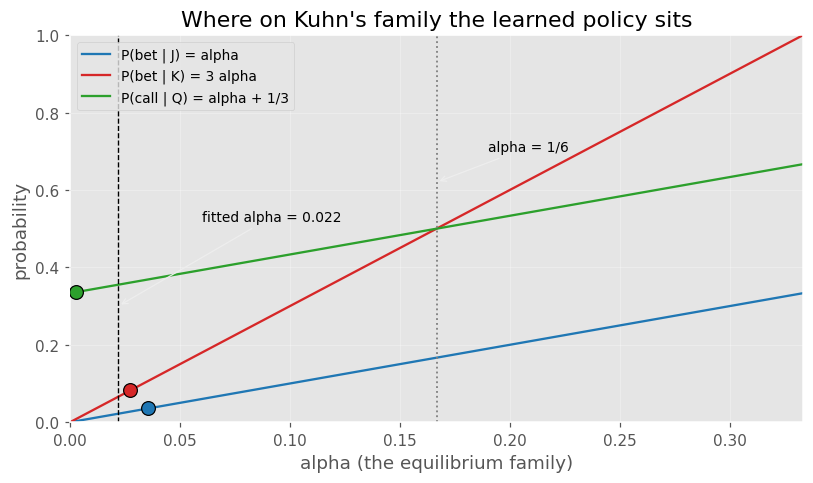

In [20]:
counts = analysis.behavioural_profile(game, 0, demo.populations[0],
                                      demo.current_meta_strategies()[0],
                                      opponent=nash1, episodes=40_000, seed=SEED)
frequency = {i: counts[i][1] / counts[i].sum() for i in game.all_infosets(0)}

estimates = {'from betting the jack (alpha)': frequency['0'],
             'from betting the king (3 alpha)': frequency['2'] / 3,
             'from calling the queen (alpha + 1/3)': frequency['1pb'] - 1 / 3}
display(pd.DataFrame({'estimate of alpha': estimates}).round(4))

alpha_hat = max(0.0, float(np.mean(list(estimates.values()))))
print(f'Fitted equilibrium parameter: alpha = {alpha_hat:.4f} '
      f'(the family is valid for alpha in [0, 1/3])')

fitted0, _fitted1 = kuhn_nash_policies(alpha_hat)
rows = []
for infoset in game.all_infosets(0):
    rows.append({
        'information set': infoset,
        'meaning': game.describe_infoset(infoset),
        'visits': int(counts[infoset].sum()),
        'P(bet) learned': round(float(frequency[infoset]), 3),
        f'P(bet) at alpha={alpha_hat:.3f}':
            round(float(fitted0.action_probs(infoset, ('p', 'b'))[1]), 3),
        'P(bet) at alpha=1/6':
            round(float(nash0.action_probs(infoset, ('p', 'b'))[1]), 3),
    })
behaviour_table = pd.DataFrame(rows)
display(behaviour_table)

fitted_gap = (behaviour_table['P(bet) learned']
              - behaviour_table[f'P(bet) at alpha={alpha_hat:.3f}']).abs().max()
arbitrary_gap = (behaviour_table['P(bet) learned']
                 - behaviour_table['P(bet) at alpha=1/6']).abs().max()
print(f'Largest deviation from the fitted member    : {fitted_gap:.3f}')
print(f'Largest deviation from the alpha=1/6 member : {arbitrary_gap:.3f}')

grid = np.linspace(0, 1 / 3, 100)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(grid, grid, color='#1f77b4', label='P(bet | J) = alpha')
ax.plot(grid, 3 * grid, color='#d62728', label='P(bet | K) = 3 alpha')
ax.plot(grid, grid + 1 / 3, color='#2ca02c', label='P(call | Q) = alpha + 1/3')
for value, implied, colour in ((frequency['0'], frequency['0'], '#1f77b4'),
                               (frequency['2'], frequency['2'] / 3, '#d62728'),
                               (frequency['1pb'], frequency['1pb'] - 1 / 3, '#2ca02c')):
    ax.plot(implied, value, 'o', color=colour, markersize=9,
            markeredgecolor='black', markeredgewidth=0.8, zorder=5)
ax.axvline(alpha_hat, color='black', linestyle='--', linewidth=0.9)
ax.axvline(1 / 6, color='grey', linestyle=':', linewidth=1.2)
ax.annotate(f'fitted alpha = {alpha_hat:.3f}', xy=(alpha_hat, 0.30),
            xytext=(0.06, 0.52), fontsize=9,
            arrowprops=dict(arrowstyle='->', linewidth=0.8))
ax.annotate('alpha = 1/6', xy=(1 / 6, 0.62), xytext=(0.19, 0.70), fontsize=9,
            arrowprops=dict(arrowstyle='->', linewidth=0.8))
ax.set_xlim(0, 1 / 3)
ax.set_ylim(0, 1.0)
ax.set_xlabel('alpha (the equilibrium family)')
ax.set_ylabel('probability')
ax.set_title("Where on Kuhn's family the learned policy sits")
ax.legend(fontsize=9, loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח האסטרטגיה שנלמדה:</p>
<ul>
<li>שלוש ההערכות ל-alpha הן 0.0357, 0.0274 ו-0.0028, וממוצען 0.0220 — בתחתית טווח [0, 1/3]. המדיניות כמעט אינה מבלפת בג'ק</li>
<li>הסטייה מהאיבר המותאם 0.019, ומהאיבר alpha=1/6 0.418 — פי 22. בחירת האיבר להשוואה קובעת אם המדיניות נראית מושלמת או שבורה</li>
<li>ההערכה מהמלכה היא החלשה: היא מחסרת 1/3 ממספר שקרוב ל-1/3, ולכן רעש של 0.019 בהסתברות הופך לשגיאה יחסית ענקית ב-alpha</li>
<li>בשלוש קבוצות המידע הנותרות שלוש העמודות זהות — 0, 0 ו-1. אלה הפעולות הנשלטות, והמדיניות שנלמדה מדייקת בכולן</li>
<li>שום דבר בלולאת PSRO לא רמז על המשפחה — חמשת מודולי האימון אינם מזכירים את kuhn_nash_policies, והיא משמשת רק להערכה</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ 5,000 ידיים, מסווג כל אחת לדפוס אסטרטגי, ומפרק את ערך המשחק בין הדפוסים. בסוף דוגמה אחת מכל סוג.</p>
</div>

Behaviour frequencies over 5,000 hands:


,hands,share,mean_payoff,contribution
behaviour,,,,
check-check showdown,2574,0.5148,0.408,0.2100
check-fold to a bet,1627,0.3254,-1.000,-0.3254
check-call,339,0.0678,2.000,0.1356
crying call,265,0.0530,-2.000,-0.1060
value bet,135,0.0270,1.207,0.0326
bluff (bet the weaker card),60,0.0120,-0.950,-0.0114


One concrete example of each behaviour:


,behaviour,P0 card,P1 card,sequence,payoff to P0
0,bluff (bet the weaker card),J,K,P0 bet/call -> P1 bet/call,-2.0
1,check-call,K,J,P0 check/fold -> P1 bet/call -> P0 bet/call,2.0
2,check-check showdown,J,Q,P0 check/fold -> P1 check/fold,-1.0
3,check-fold to a bet,Q,K,P0 check/fold -> P1 bet/call -> P0 check/fold,-1.0
4,crying call,Q,K,P0 check/fold -> P1 bet/call -> P0 bet/call,-2.0
5,value bet,K,Q,P0 bet/call -> P1 bet/call,2.0


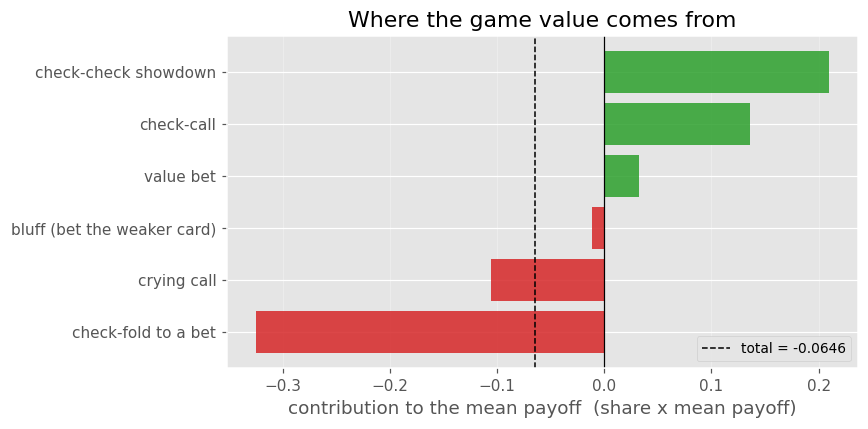

In [21]:
hands = analysis.play_example_hands(game, demo.populations[0],
                                    demo.current_meta_strategies()[0],
                                    opponent=nash1, hands=5_000, seed=SEED)

pattern_table = (hands.groupby('behaviour')
                 .agg(hands=('payoff to P0', 'size'),
                      share=('payoff to P0', lambda s: round(len(s) / len(hands), 4)),
                      mean_payoff=('payoff to P0', lambda s: round(s.mean(), 3)))
                 .sort_values('hands', ascending=False))
pattern_table['contribution'] = (pattern_table['share']
                                 * pattern_table['mean_payoff']).round(4)
print('Behaviour frequencies over 5,000 hands:')
display(pattern_table)

print('One concrete example of each behaviour:')
display(hands.groupby('behaviour', as_index=False).first())

order = pattern_table.sort_values('contribution')
colours = ['#d62728' if value < 0 else '#2ca02c' for value in order['contribution']]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(order.index, order['contribution'], color=colours, alpha=0.85)
ax.axvline(0.0, color='black', linewidth=0.8)
ax.axvline(pattern_table['contribution'].sum(), color='black', linestyle='--',
           linewidth=1, label=f"total = {pattern_table['contribution'].sum():.4f}")
ax.set_xlabel('contribution to the mean payoff  (share x mean payoff)')
ax.set_title('Where the game value comes from')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח דפוסי המשחק:</p>
<ul>
<li>84 אחוז מהידיים נגמרות בלי הימור יזום — 51.5 אחוז check משני הצדדים ו-32.5 אחוז קיפול מול הימור. עקבי עם alpha 0.022</li>
<li>הפירוק מסתכם ב-0.0646-, במרחק רעש דגימה מ-1/18-. ששת הדפוסים מסבירים את ערך המשחק במלואו</li>
<li>check-check מניב 0.408+ ולא אפס: שחקן 1 מהמר על מלך אחרי check תמיד, ולכן שואודאון שקט מעיד שאין לו מלך</li>
<li>הניקוז הגדול הוא הקיפול מול הימור, 0.3254-, וכל יד כזאת מפסידה בדיוק 1.000 — האנטה, בלי שונות</li>
<li>הבלוף ב-1.2 אחוז מפסיד 0.950, וזה אינו כשל: בלעדיו היריב מקפל מול כל הימור, והימור הערך לא היה מרוויח 1.207. שיווי המשקל מחייב אותו</li>
<li>ה-crying call ב-5.3 אחוז מפסיד 2 בכל פעם — המחיר של תדירות התשלום שהמשפחה מחייבת, beta = alpha + 1/3</li>
<li>בטבלת הדוגמאות לבלוף ולהימור הערך רצף פעולות זהה — bet ואז call. היריב אינו רואה הבדל, וזו כל התכלית</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>9.1 האם המדיניות שנלמדה נמצאת על הישר של Kuhn</p>
<p>Kuhn (1950) מצא משפחת שיווי משקל חד-פרמטרית: alpha לבלוף ב-J, beta לתשלום ב-Q, ו-gamma להימור ב-K, בשני אילוצים:</p>
<p>alpha = gamma / 3 וגם beta = gamma / 3 + 1/3</p>
<p>לשחקן 1 אין משפחה: שיווי המשקל שלו יחיד — בלוף ב-J אחרי check ותשלום ב-Q מול הימור, שניהם 1/3.</p>
<p>זהו אימות שעקומת ה-exploitability אינה נותנת: אפס אומר שקשה לנצל את המדיניות, והישר אומר שקשה לנצל אותה מהסיבה ש-Kuhn זיהה.</p>
<p>הפרמטרים אינם ממוצע הרכיבים: רכיב משפיע רק בצמתים שמגיע אליהם, ולכן ההסתברויות משוקללות בהסתברות ההגעה — הן שקולות-מימוש לתערובת.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מחלץ את חמשת הפרמטרים מהריצה המלאה, מודד את השארית מול האילוצים של Kuhn, ומוסיף את חמש הפעולות שבהן אין חופש.</p>
</div>

In [22]:
parameters0 = kuhn_behaviour_parameters(game, demo.populations[0],
                                        demo.meta_strategies[0], 0)
parameters1 = kuhn_behaviour_parameters(game, demo.populations[1],
                                        demo.meta_strategies[1], 1)

rows = [
    {'player': 0, 'parameter': 'alpha  (bluff the jack)',
     'learned': parameters0['alpha'], 'Kuhn requires': parameters0['alpha_from_gamma'],
     'rule': 'gamma / 3'},
    {'player': 0, 'parameter': 'beta   (call with the queen)',
     'learned': parameters0['beta'], 'Kuhn requires': parameters0['beta_from_gamma'],
     'rule': 'gamma / 3 + 1/3'},
    {'player': 0, 'parameter': 'gamma  (bet the king)',
     'learned': parameters0['gamma'], 'Kuhn requires': float('nan'),
     'rule': 'free parameter'},
    {'player': 1, 'parameter': 'xi     (bluff the jack)',
     'learned': parameters1['xi'], 'Kuhn requires': 1 / 3, 'rule': 'unique: 1/3'},
    {'player': 1, 'parameter': 'eta    (call with the queen)',
     'learned': parameters1['eta'], 'Kuhn requires': 1 / 3, 'rule': 'unique: 1/3'},
]
kuhn_table = pd.DataFrame(rows)
kuhn_table['deviation'] = (kuhn_table['learned'] - kuhn_table['Kuhn requires']).abs()
display(kuhn_table.round(4))

dominated_table = pd.DataFrame([
    {'player': 0, 'action': 'bet the queen first', 'learned': parameters0['bet_queen_first'],
     'equilibrium demands': 0.0},
    {'player': 0, 'action': 'fold the jack to a bet', 'learned': parameters0['fold_jack'],
     'equilibrium demands': 1.0},
    {'player': 0, 'action': 'call with the king', 'learned': parameters0['call_king'],
     'equilibrium demands': 1.0},
    {'player': 1, 'action': 'bet the king after a check',
     'learned': parameters1['bet_king_after_check'], 'equilibrium demands': 1.0},
    {'player': 1, 'action': 'call with the jack', 'learned': parameters1['call_jack'],
     'equilibrium demands': 0.0},
])
print('Behaviour that the equilibrium fixes completely, with no freedom at all:')
display(dominated_table.round(4))

print(f"Player 0 residual from Kuhn's line : {parameters0['residual']:.4f}")
print(f"Player 1 distance from (1/3, 1/3)  : {parameters1['residual']:.4f}")
print(f"Implied member of the family, alpha: {parameters0['alpha']:.4f}  "
      f"(the family runs over [0, 1/3])")

,player,parameter,learned,Kuhn requires,rule,deviation
0,0,alpha (bluff the jack),0.0361,0.0266,gamma / 3,0.0095
1,0,beta (call with the queen),0.3322,0.3600,gamma / 3 + 1/3,0.0277
2,0,gamma (bet the king),0.0799,NaN,free parameter,NaN
3,1,xi (bluff the jack),0.3648,0.3333,unique: 1/3,0.0314
4,1,eta (call with the queen),0.3552,0.3333,unique: 1/3,0.0219


Behaviour that the equilibrium fixes completely, with no freedom at all:


,player,action,learned,equilibrium demands
0,0,bet the queen first,0.0,0.0
1,0,fold the jack to a bet,1.0,1.0
2,0,call with the king,1.0,1.0
3,1,bet the king after a check,1.0,1.0
4,1,call with the jack,0.0,0.0


Player 0 residual from Kuhn's line : 0.0372
Player 1 distance from (1/3, 1/3)  : 0.0533
Implied member of the family, alpha: 0.0361  (the family runs over [0, 1/3])


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קריאת הפרמטרים:</p>
<ul>
<li>שחקן 0: alpha 0.0361 מול 0.0266 הנדרש, beta 0.3322 מול 0.3600, ושארית כוללת 0.0372 על משפחה שנפרשת על 1/3</li>
<li>חמש הפעולות ללא דרגות חופש יוצאות מדויקות — 0, 1, 1, 1, 0. אלה לא כוונו, הן צצו מהאופטימיזציה</li>
<li>שארית שחקן 1 גדולה יותר, 0.0533, אף ששיווי המשקל שלו יחיד — והסיבה מבנית: הוא נמדד מול נקודה, ושחקן 0 מול ישר</li>
<li>מה שראוי לדווח הוא השארית ולא הפרמטר: alpha יכול להיות כל ערך בטווח, אבל השארית חייבת להיות אפס</li>
<li>alpha כאן 0.0361, ובתא הדגימה 0.0220 — החילוץ המדויק מול ממוצע שלושה אומדים מדגמיים, שאחד מהם רע</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>הערה על הרצת הניסויים שלהלן:</p>
<ul>
<li>חמשת הניסויים והאבלציות כוללים 131 הרצות PSRO, מריצות של שנייה עם אורקל מדויק ועד ריצות בתקציב אורקל 50,000</li>
<li>כל ניסוי נשמר לקובץ CSV בסיומו. אם החיבור מתנתק באמצע, הרצה חוזרת של המחברת טוענת את מה שכבר הושלם וממשיכה מהניסוי הבא</li>
<li>results מקבלת מטריצות, מטא-אסטרטגיות וטבלאות מדדים, ו-configs קובץ לכל ניסוי — שתיהן נדרשות בסעיף 9 במפרט</li>
<li>כדי לחשב הכל מחדש מאפס יש למחוק את תיקיית results</li>
</ul>
</div>

In [23]:
existing = sorted(os.listdir(RESULTS_PATH)) if os.path.isdir(RESULTS_PATH) else []
print('Existing results:', existing or 'none, the experiments will be computed')
print('Available cores :', os.cpu_count())
experiments_started = time.time()

Existing results: none, the experiments will be computed
Available cores : 2


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10.1 ניסוי 1 — self-play מול PSRO תחת אותו תקציב</p>
<p>שתי הזרועות זהות מלבד פותר המטא: אותו oracle, תקציב, הערכה ו-seeds. כל הפרש מיוחס לשמירת האוכלוסייה ולפתירתה. זו שאלת המחקר.</p>
<ul>
<li>חמישה seeds, מה שמאפשר מבחן סטטיסטי ולא רק השוואת ממוצעים</li>
<li>המדדים: תשואה ממוצעת מול האוכלוסייה, במקרה הגרוע, exploitability, רגישות לבחירת היריב (סטיית תקן), וביצועים מול יריבים שלא נראו</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ את הזרועות על חמישה seeds: אחד-עשר מדדים בממוצע ובסטיית תקן, ה-exploitability לאיטרציה, והגרף המרכזי של הפרויקט.</p>
</div>

  [1/10] self_play_s0
  [2/10] self_play_s1
  [3/10] self_play_s2
  [4/10] self_play_s3
  [5/10] self_play_s4
  [6/10] nash_s0
  [7/10] nash_s1
  [8/10] nash_s2
  [9/10] nash_s3
  [10/10] nash_s4
Comparison over 5 seeds (mean and standard deviation):


group                        nash  self_play
final_exploitability mean  0.0315     1.2500
                     std   0.0121     0.0000
vs_population_mean   mean -0.0231     0.1436
                     std   0.0082     0.0107
vs_population_worst  mean -0.0656    -0.4833
                     std   0.0059     0.0373
vs_unseen_mean       mean  0.1001     0.4347
                     std   0.0169     0.0822
vs_unseen_worst      mean  0.0538     0.0965
                     std   0.0200     0.0202
vs_unseen_spread     mean  0.0301     0.2465
                     std   0.0039     0.0529
vs_perturbed_worst   mean -0.0407    -0.0300
                     std   0.0023     0.0183
vs_early_worst       mean -0.0326    -0.4167
                     std   0.0216     0.0589
support              mean  4.4000     1.0000
                     std   0.5477     0.0000
entropy              mean  1.1686     0.0000
                     std   0.1543     0.0000
value_error          mean  0.0004     0.8056
                     std   0.0003     0.0000

Exploitability by iteration (mean over seeds):


group,nash,self_play
iteration,,
1,0.9167,0.9167
2,0.8000,0.8000
3,0.3387,0.3333
4,0.2751,0.8000
5,0.1609,1.0500
6,0.1173,0.6667
7,0.0766,0.3667
8,0.0624,0.9167
9,0.0425,1.2500


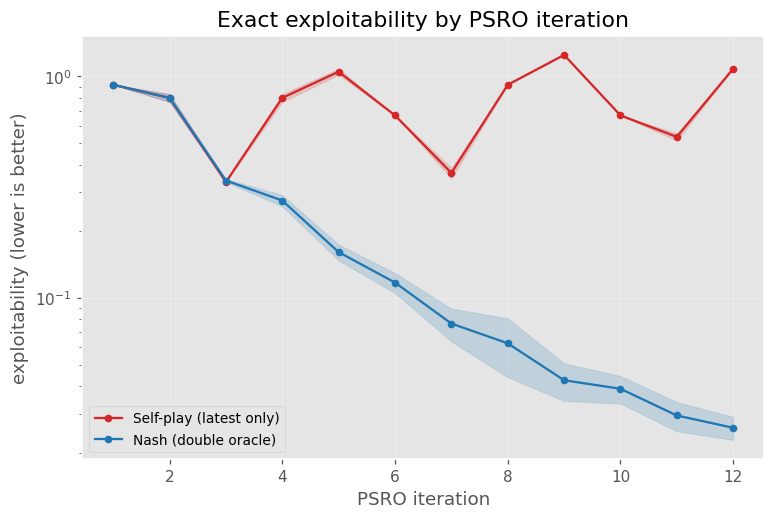

In [24]:
exp1_iterations, exp1_summary = experiments.experiment_1(seeds=EXP1_SEEDS)

metrics = ['final_exploitability', 'vs_population_mean', 'vs_population_worst',
           'vs_unseen_mean', 'vs_unseen_worst', 'vs_unseen_spread',
           'vs_perturbed_worst', 'vs_early_worst', 'support', 'entropy',
           'value_error']
print('Comparison over 5 seeds (mean and standard deviation):')
display(exp1_summary.groupby('group')[metrics].agg(['mean', 'std']).round(4).T)

print('Exploitability by iteration (mean over seeds):')
exp1_curve = exp1_iterations.pivot_table(index='iteration', columns='group',
                                         values='exploitability', aggfunc='mean')
display(exp1_curve.round(4))

analysis.plot_exploitability(exp1_iterations, groups=['self_play', 'nash'])
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>מבחן סטטיסטי על ההפרש. שלוש הערות מתודולוגיות קודמות לו:</p>
<ul>
<li>פותר self_play מחזיר וקטור יחידה על המדיניות האחרונה, והאורקל מדויק — הפתרון הסופי זהה בכל חמשת ה-seeds</li>
<li>28 מעמודות self_play יוצאות בסטיית תקן אפס מול 11 ב-nash. אלה מאפייני הפתרון; מה שמשתנה הוא האוכלוסייה שבדרך</li>
<li>מבחן t מחלק באפס בשניים מהמדדים, ולכן מדווח Mann-Whitney. עם חמישה מול חמישה 0.0075 הוא הרצפה — אי אפשר לרדת מתחתיו</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ Mann-Whitney על שישה מדדים: ממוצע, סטיית תקן, הפרש, ערך p, והאם הטווחים נחתכים. בסוף ספירת העמודות בפיזור אפס.</p>
</div>

In [25]:
rows = []
for metric in ['final_exploitability', 'vs_unseen_worst', 'vs_perturbed_worst',
               'vs_final_selfplay_worst', 'vs_population_mean', 'value_error']:
    a = exp1_summary.loc[exp1_summary['group'] == 'nash', metric].dropna()
    b = exp1_summary.loc[exp1_summary['group'] == 'self_play', metric].dropna()
    if len(a) < 2 or len(b) < 2:
        continue
    p_value = stats.mannwhitneyu(a, b, alternative='two-sided').pvalue
    overlap = (max(a.min(), b.min()) <= min(a.max(), b.max()))
    rows.append({'metric': metric,
                 'nash': round(a.mean(), 4), 'nash std': round(a.std(ddof=1), 4),
                 'self_play': round(b.mean(), 4), 'self_play std': round(b.std(ddof=1), 4),
                 'difference': round(a.mean() - b.mean(), 4),
                 'Mann-Whitney p': round(float(p_value), 4),
                 'ranges overlap': overlap})
display(pd.DataFrame(rows))

for group in ('self_play', 'nash'):
    numbers = exp1_summary[exp1_summary['group'] == group].select_dtypes('number')
    degenerate = int((numbers.std(ddof=1).fillna(0) == 0).sum())
    print(f'{group:>9} columns with zero spread across the five seeds: '
          f'{degenerate} of {numbers.shape[1]}')

,metric,nash,nash std,self_play,self_play std,difference,Mann-Whitney p,ranges overlap
0,final_exploitability,0.0315,0.0121,1.2500,0.0000,-1.2185,0.0075,False
1,vs_unseen_worst,0.0538,0.0200,0.0965,0.0202,-0.0426,0.0109,False
2,vs_perturbed_worst,-0.0407,0.0023,-0.0300,0.0183,-0.0107,0.6714,True
3,vs_final_selfplay_worst,0.0409,0.0111,0.4333,0.1369,-0.3924,0.0109,False
4,vs_population_mean,-0.0231,0.0082,0.1436,0.0107,-0.1667,0.0119,False
5,value_error,0.0004,0.0003,0.8056,0.0000,-0.8051,0.0075,False


self_play columns with zero spread across the five seeds: 28 of 56
     nash columns with zero spread across the five seeds: 11 of 56


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח ניסוי 1:</p>
<ul>
<li>ההפרש ב-exploitability פי 39.7 — 0.0315 מול 1.2500. הטווחים אינם נחתכים ו-p של Mann-Whitney 0.0075</li>
<li>שגיאת ערך המשחק חדה יותר: 0.0004 מול 0.8056. self-play אינו רק ניתן לניצול — מתכנס לערך שגוי, כי מודד את עצמו מול עצמו</li>
<li>לא רק הערך הסופי אלא צורת העקומה: PSRO יורד בהתמדה מ-0.92 ל-0.026, self-play מתנודד ללא כיוון ומסיים ב-1.08</li>
<li>עדות המחזוריות הישירה: self-play מפסיד 0.4167- לגרסאות מוקדמות של עצמו, מול 0.0326- ב-PSRO — פי שלוש-עשרה</li>
<li>ממצא הפוך: מול יריבים חלשים self-play מנצח יותר — 0.097+ מול 0.054+ בלא-נראו, ו-0.433+ מול 0.041+ מול לומד self-play</li>
<li>זו ההבחנה בין חוסן לניצול: מדיניות שיווי משקל אינה מנסה לנצל טעויות, היא מבטיחה שלא ינצלו אותה</li>
<li>האנטרופיה מסבירה את המנגנון: 1.17 מול 0.00. self-play מסיים במדיניות טהורה יחידה, וכל מדיניות טהורה ב-Kuhn ניתנת לניצול</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10.1.1 דיווח סטטיסטי: אומדני רווח במקום ערכי p</p>
<p>הסטנדרט: Muller ואחרים (ICLR 2020) שתיים, McAleer ואחרים (NeurIPS 2020) שלוש, Balduzzi ואחרים (ICML 2019) כלום. בוטסטרפ — אף אחד.</p>
<p>Agarwal ואחרים (NeurIPS 2021) המליצו: רווח, IQM וגודל אפקט. Henderson ואחרים (AAAI 2018): פיצול עשר הרצות זהות לשתיים מייצר מובהקות.</p>
<p>שלושת המדדים מחושבים כאן, וזול לעשות זאת במשחק בגודל הזה. הדיווח יוצא מחמיר מכל מאמר שנסקר.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מדווח לכל מדד IQM, רווח בוטסטרפ, וההסתברות ש-PSRO מנצח. better when קובעת את הכיוון, כי מחצית המדדים ממוזערים.</p>
</div>

In [26]:
METRICS = {
    'final_exploitability': 'lower',
    'population_exploitability': 'lower',
    'value_error': 'lower',
    'vs_unseen_worst': 'higher',
    'vs_early_worst': 'higher',
}

rows = []
for metric, better in METRICS.items():
    a = exp1_summary.loc[exp1_summary['group'] == 'nash', metric].dropna().values
    b = exp1_summary.loc[exp1_summary['group'] == 'self_play', metric].dropna().values
    if len(a) < 2 or len(b) < 2:
        continue
    a_iqm, a_low, a_high = analysis.bootstrap_ci(a, analysis.iqm)
    b_iqm, b_low, b_high = analysis.bootstrap_ci(b, analysis.iqm)
    probability = (analysis.probability_of_improvement(a, b) if better == 'lower'
                   else analysis.probability_of_improvement(b, a))
    rows.append({
        'metric': metric,
        'better when': better,
        'nash IQM': round(a_iqm, 4),
        'nash 95% CI': f'[{a_low:.4f}, {a_high:.4f}]',
        'self_play IQM': round(b_iqm, 4),
        'self_play 95% CI': f'[{b_low:.4f}, {b_high:.4f}]',
        'P(nash wins)': round(probability, 3),
    })
robust_table = pd.DataFrame(rows)
display(robust_table)

won = robust_table.loc[robust_table['P(nash wins)'] == 1.0, 'metric'].tolist()
lost = robust_table.loc[robust_table['P(nash wins)'] == 0.0, 'metric'].tolist()
print(f'Metrics where every nash run beat every self-play run: {len(won)}')
print(f'  {", ".join(won)}')
if lost:
    print(f'Metrics where the reverse holds: {", ".join(lost)}')
print()
print('P(nash wins) = 1.000 is the strongest statement five seeds per arm can')
print('support, and it assumes nothing about the shape of the distribution.')

,metric,better when,nash IQM,nash 95% CI,self_play IQM,self_play 95% CI,P(nash wins)
0,final_exploitability,lower,0.0316,"[0.0184, 0.0435]",1.2500,"[1.2500, 1.2500]",1.0
1,population_exploitability,lower,0.0000,"[-0.0000, 0.0000]",0.0819,"[0.0819, 0.0876]",1.0
2,value_error,lower,0.0004,"[0.0002, 0.0008]",0.8056,"[0.8056, 0.8056]",1.0
3,vs_unseen_worst,higher,0.0561,"[0.0310, 0.0711]",0.0940,"[0.0817, 0.1187]",0.0
4,vs_early_worst,higher,-0.0256,"[-0.0580, -0.0178]",-0.4167,"[-0.4722, -0.3611]",1.0


Metrics where every nash run beat every self-play run: 4
  final_exploitability, population_exploitability, value_error, vs_early_worst
Metrics where the reverse holds: vs_unseen_worst

P(nash wins) = 1.000 is the strongest statement five seeds per arm can
support, and it assumes nothing about the shape of the distribution.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קריאת הסטטיסטיקה:</p>
<ul>
<li>ארבעה מחמשת המדדים ב-1.000: כל הרצת PSRO מנצחת כל הרצת self-play. זו התקרה לחמישה seeds, בלי הנחה על ההתפלגות</li>
<li>החמישי הפוך ונשאר בכוונה: מול יריבים שלא נראו self-play מנצח בכל חמש. בלי עמודת הכיוון, הפסד כזה נספר כניצחון</li>
<li>רווחי הסמך אינם חופפים באף אחד מחמשת המדדים — טענה חזקה מערך p, כי היא מציגה גם את גודל ההפרש</li>
<li>רווחי self_play באפס רוחב — [1.2500, 1.2500] ו-[0.8056, 0.8056]. חמש הרצות זהות, ולכן הרווח מודד דטרמיניזם ולא אי-ודאות</li>
<li>הממוצע רגיש להרצה חריגה יחידה, ולכן IQM: הוא מוותר על שתיים מחמש, בעוד החציון מוותר על ארבע</li>
<li>population_exploitability של nash אפס מדויק — האוכלוסייה מכילה תמיכה של שיווי משקל, ו-0.0316 הם כולם מחיר בחירת מושג הפתרון</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10.2 ניסוי 2 — השוואת פותרי המטא-אסטרטגיה</p>
<p>שמונת הפותרים באותו תקציב, חמישה seeds. המדדים הנדרשים: exploitability לאיטרציה, האוכלוסייה, ערך המטא-משחק, אנטרופיה, וזמן ריצה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ את שמונת הפותרים: תשעה מדדים ממוינים לפי exploitability עם רווח t, ה-exploitability לאיטרציה, וגרפי exploitability ואנטרופיה.</p>
</div>

  [1/40] self_play_s0
  [2/40] self_play_s1
  [3/40] self_play_s2
  [4/40] self_play_s3
  [5/40] self_play_s4
  [6/40] uniform_s0
  [7/40] uniform_s1
  [8/40] uniform_s2
  [9/40] uniform_s3
  [10/40] uniform_s4
  [11/40] fictitious_play_s0
  [12/40] fictitious_play_s1
  [13/40] fictitious_play_s2
  [14/40] fictitious_play_s3
  [15/40] fictitious_play_s4
  [16/40] nash_s0
  [17/40] nash_s1
  [18/40] nash_s2
  [19/40] nash_s3
  [20/40] nash_s4
  [21/40] replicator_s0
  [22/40] replicator_s1
  [23/40] replicator_s2
  [24/40] replicator_s3
  [25/40] replicator_s4
  [26/40] projected_replicator_s0
  [27/40] projected_replicator_s1
  [28/40] projected_replicator_s2
  [29/40] projected_replicator_s3
  [30/40] projected_replicator_s4
  [31/40] regret_matching_s0
  [32/40] regret_matching_s1
  [33/40] regret_matching_s2
  [34/40] regret_matching_s3
  [35/40] regret_matching_s4
  [36/40] rectified_nash_s0
  [37/40] rectified_nash_s1
  [38/40] rectified_nash_s2
  [39/40] rectified_nash_s3
  [40/4

,final_exploitability,final_value,value_error,entropy,support,population,diversity_weighted,vs_unseen_worst,wall_seconds,expl. 95% CI
group,,,,,,,,,,
fictitious_play,0.0282,-0.0557,0.0003,1.4257,8.6,13.0,0.2271,0.0565,6.6185,0.0118
nash,0.0315,-0.0555,0.0004,1.1686,4.4,13.0,0.2277,0.0538,7.7405,0.0150
regret_matching,0.0516,-0.0545,0.0014,1.5189,13.0,13.0,0.2105,0.0556,8.2752,0.0391
replicator,0.0947,-0.0519,0.0037,1.4990,10.4,13.0,0.1923,0.0493,8.7701,0.0674
projected_replicator,0.1107,-0.0597,0.0043,1.8505,13.0,13.0,0.1771,0.0304,10.1886,0.0285
uniform,0.1462,-0.0434,0.0121,2.5649,13.0,13.0,0.2098,0.0775,6.0530,0.0469
rectified_nash,0.5178,0.2014,0.3014,0.2459,1.8,13.0,0.0934,0.0644,6.1856,0.2991
self_play,1.2500,0.7500,0.8056,0.0000,1.0,13.0,0.0000,0.0965,5.9615,0.0000


Exploitability by iteration (mean over seeds):


group,fictitious_play,nash,projected_replicator,rectified_nash,regret_matching,replicator,self_play,uniform
iteration,,,,,,,,
1,0.9167,0.9167,0.9167,0.9167,0.9167,0.9167,0.9167,0.9167
2,0.7998,0.8000,0.7825,0.8000,0.8000,0.8000,0.8000,0.6250
3,0.3333,0.3387,0.3306,0.3333,0.3608,0.3466,0.3333,0.4389
4,0.2354,0.2751,0.2229,0.4675,0.2616,0.3585,0.8000,0.3458
5,0.1143,0.1609,0.1516,0.3772,0.1645,0.2251,1.0500,0.2633
6,0.0712,0.1173,0.1321,0.3693,0.1265,0.1864,0.6667,0.2333
7,0.0562,0.0766,0.1197,0.4015,0.0750,0.2521,0.3667,0.2000
8,0.0646,0.0624,0.1161,0.4333,0.0339,0.1391,0.9167,0.1896
9,0.0332,0.0425,0.1260,0.4343,0.0355,0.1436,1.2500,0.1907


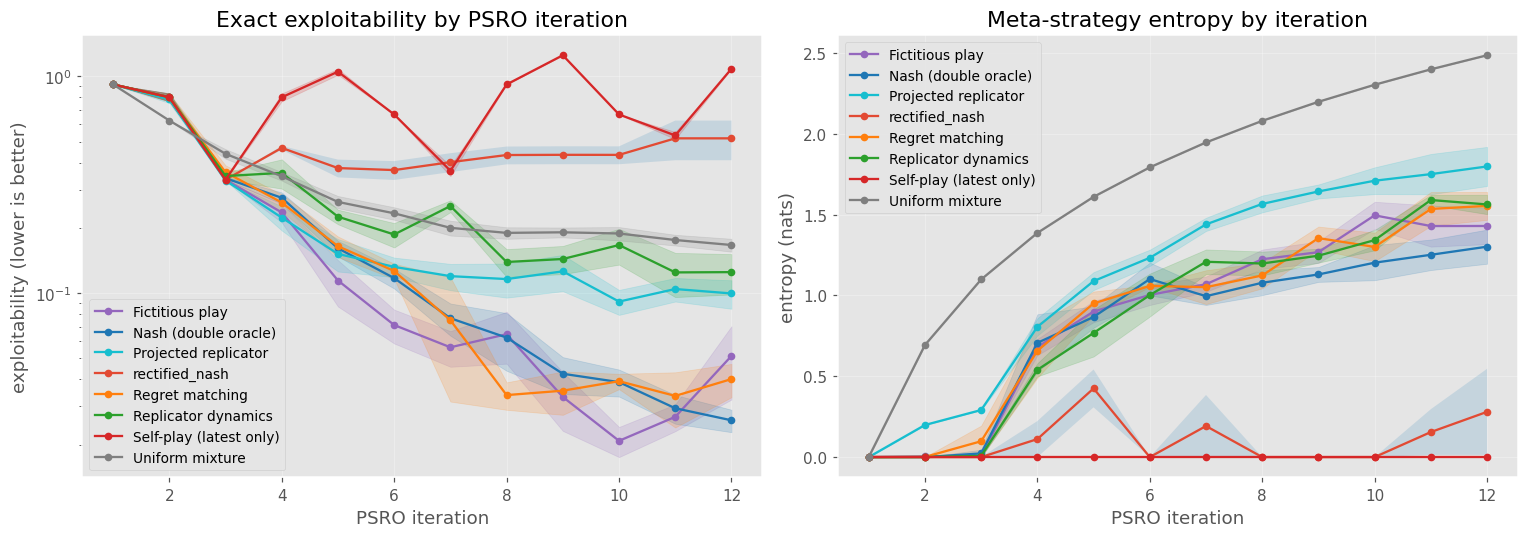

In [27]:
exp2_iterations, exp2_summary = experiments.experiment_2(seeds=EXP_SEEDS)

metrics = ['final_exploitability', 'final_value', 'value_error', 'entropy',
           'support', 'population', 'diversity_weighted', 'vs_unseen_worst',
           'wall_seconds']
exp2_table = exp2_summary.groupby('group')[metrics].mean().round(4)
half_width = stats.t.ppf(0.975, df=len(EXP_SEEDS) - 1)
exp2_table['expl. 95% CI'] = (
    half_width * exp2_summary.groupby('group')['final_exploitability'].sem()).round(4)
print('Solver comparison, sorted by final exploitability '
      f'(CI half-width from Student-t, df={len(EXP_SEEDS) - 1}):')
display(exp2_table.sort_values('final_exploitability'))

print('Exploitability by iteration (mean over seeds):')
display(exp2_iterations.pivot_table(index='iteration', columns='group',
                                    values='exploitability', aggfunc='mean').round(4))

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
analysis.plot_exploitability(exp2_iterations, ax=axes[0])
analysis.plot_metric_by_iteration(exp2_iterations, 'entropy0', logy=False, ax=axes[1],
                                  title='Meta-strategy entropy by iteration',
                                  ylabel='entropy (nats)')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<ul>
<li>fictitious_play מוביל עם 0.0282 מול 0.0315 של nash, אבל רווחי הסמך 0.0118 ו-0.0150 חופפים כמעט לחלוטין.</li>
<li>גם regret_matching בתוך הטווח: 0.0516 עם רווח 0.0391 נוגע בשניהם. שלושת הראשונים אינם ניתנים להפרדה בחמישה seeds.</li>
<li>עמודת value_error מאשרת את המיון, עולה מונוטונית מ-0.0003 ל-0.8056 לאורך כל שמונה השורות ללא היפוך אחד.</li>
<li>nash הוא היחיד שיורד בכל איטרציה, 0.9167 עד 0.0259 ברצף. אצל כל שבעת האחרים יש לפחות עלייה אחת.</li>
<li>השורה האחרונה אינה העמודה המסכמת: הטבלה נעצרת על שתים-עשרה מדיניויות והסיכום נמדד על שלוש-עשרה, ולכן 0.0513 מול 0.0282.</li>
<li>rectified_nash ו-self_play נופלים מתחת ל-uniform, 0.5178 ו-1.2500 מול 0.1462, עם תמיכה 1.8 ו-1.0 בלבד.</li>
<li>אנטרופיה אינה מטרה בפני עצמה: uniform מגיע ל-2.5649 nats והוא רק שישי, בעוד nash משיג 0.0315 עם תמיכה 4.4.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>עמודת wall_seconds היא זמן האימון שבמפרט, אך מזוהמת מהרצה מקבילית. ה-oracle וההערכה זהים, ולכן התא הבא מודד את עלות הפותר.</p>
</div>

In [28]:
rows = []
for size in TIMING_SIZES:
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(size=(size, size))
    matrix = matrix - matrix.T
    row = {'population size': size}
    for name, solver in SOLVERS.items():
        start = time.perf_counter()
        for _ in range(5):
            solver(matrix)
        row[name] = round((time.perf_counter() - start) / 5 * 1000, 2)
    rows.append(row)

timing_table = pd.DataFrame(rows).set_index('population size')
print('Mean solve time in milliseconds, measured serially:')
display(timing_table)

Mean solve time in milliseconds, measured serially:


,uniform,self_play,fictitious_play,nash,replicator,projected_replicator,regret_matching,rectified_nash
population size,,,,,,,,
4,0.01,0.0,34.59,4.60,171.05,300.18,138.54,4.70
8,0.01,0.0,30.05,4.80,167.60,315.28,140.74,4.61
16,0.01,0.0,34.68,4.82,299.13,560.26,269.91,5.34
32,0.01,0.0,36.77,6.97,195.70,367.83,167.07,7.54
64,0.01,0.0,47.09,19.10,216.68,371.02,169.20,17.18


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח ניסוי 2:</p>
<ul>
<li>fictitious_play מוביל עם 0.0282 מול 0.0315 של nash, אבל רווחי הסמך 0.0118 ו-0.0150 חופפים כמעט לחלוטין.</li>
<li>fictitious_play ראשון בזכות תערובת רכה, המוגנת מרעש במטריצה, ואילו nash מנצל אותה. אבלציית few_eval_episodes מאשרת זאת.</li>
<li>עמודת value_error מאשרת את המיון, עולה מונוטונית מ-0.0003 ל-0.8056 לאורך כל שמונה השורות ללא היפוך אחד.</li>
<li>nash הוא היחיד שיורד בכל איטרציה, 0.9167 עד 0.0259 ברצף. אצל כל שבעת האחרים יש לפחות עלייה אחת.</li>
<li>אנטרופיה אינה מטרה בפני עצמה: uniform מגיע ל-2.5649 nats והוא רק שישי, בעוד nash משיג 0.0315 עם תמיכה 4.4.</li>
<li>uniform ו-self_play ב-0.01 ו-0.0 מילישניות אינם פותרים. nash גדל מ-4.60 ל-19.10 עם הגודל, ו-projected_replicator מ-300.18 ל-371.02, עם קפיצה בגודל 16 שמופיעה בשלושת פותרי הרפליקטור יחד ולכן היא רעש מכונה.</li>
<li>אצל nash הפותר כאחוז מהריצה ואצל projected_replicator כשליש. הסדר זהה ל-wall_seconds, פרט ל-nash ו-fictitious_play הזניחים.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10.2.1 השוואה נטולת פותר, ושחזור כשל מתועד בספרות</p>
<p>שני דברים נבחנים כאן, שניהם מהספרות.</p>
<ul>
<li>הטבלה של ניסוי 2 מדרגת כל פותר לפי מושג הפתרון של עצמו. Wang, Ma ו-Wellman (AAMAS 2022) מראים שדירוג כזה עלול להתהפך.</li>
<li>final_exploitability מודד את התערובת שהפותר בחר, ו-population_exploitability את הטוב ביותר שהאוכלוסייה יכלה לבטא.</li>
<li>rectified_nash הוא PSRO_rN מ-Balduzzi ואחרים (ICML 2019), שבו לומד מתאמן רק מול יריבים שאינו מפסיד להם. נכלל משום שנכשל.</li>
<li>McAleer ואחרים (NeurIPS 2020) הוכיחו שאינו מתכנס תמיד, ו-Muller ואחרים (ICLR 2020) מצאו שהוא נתקע בלולאה ב-Kuhn.</li>
<li>לכן המדד כאן הוא מספר המדיניויות ההתנהגותיות השונות. הכשל אינו פרישה גרועה אלא אוכלוסייה שמפסיקה לגדול.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מוסיף שלושה מדדי גיוון מהספרות: ספירת מדיניויות שונות, effective diversity של Balduzzi, וקרדינליות DPP של Perez-Nieves.</p>
</div>

,final_exploitability,population_exploitability,unique_policies,population,effective_diversity,dpp_cardinality,exploitability_rises
group,,,,,,,
fictitious_play,0.0282,0.0000,8.2,13.0,0.0503,1.8988,4.2
nash,0.0315,0.0000,9.0,13.0,0.0426,1.9202,2.0
regret_matching,0.0516,0.0000,8.4,13.0,0.0453,2.0106,3.6
replicator,0.0947,0.0000,7.8,13.0,0.0525,2.0067,4.2
projected_replicator,0.1107,0.0000,7.2,13.0,0.0347,1.9131,4.0
uniform,0.1462,0.0091,6.0,13.0,0.0585,1.9005,2.0
rectified_nash,0.5178,0.0804,5.4,13.0,0.0099,1.6779,2.4
self_play,1.2500,0.0836,8.0,13.0,0.0000,1.8937,6.0


Solvers whose population already contains a full-game equilibrium: 5 of 8
  fictitious_play, nash, regret_matching, replicator, projected_replicator
For these, every point of the final exploitability is the cost of choosing
the mixture, not of collecting the policies.

Fewest distinct policies discovered: rectified_nash (5.4 distinct out of 13.0 added)


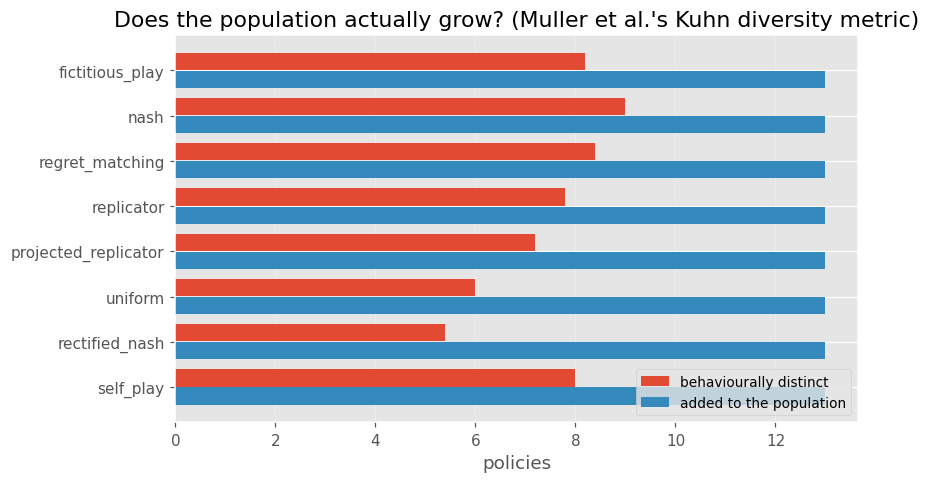

In [29]:
columns = ['final_exploitability', 'population_exploitability', 'unique_policies',
           'population', 'effective_diversity', 'dpp_cardinality',
           'exploitability_rises']
solver_means = (exp2_summary.groupby('group')[columns]
                .mean()
                .sort_values('final_exploitability'))
solver_table = solver_means.round(4) + 0.0
display(solver_table)

adequate = solver_means.index[solver_means['population_exploitability'] < 1e-6]
print(f'Solvers whose population already contains a full-game equilibrium: '
      f'{len(adequate)} of {len(solver_table)}')
print(f'  {", ".join(adequate)}')
print('For these, every point of the final exploitability is the cost of choosing')
print('the mixture, not of collecting the policies.')

worst_growth = solver_means['unique_policies'].idxmin()
print(f'\nFewest distinct policies discovered: {worst_growth} '
      f'({solver_means.loc[worst_growth, "unique_policies"]:.1f} distinct out of '
      f'{solver_means.loc[worst_growth, "population"]:.1f} added)')

fig, ax = plt.subplots(figsize=(8, 4.5))
order = solver_table.index
ax.barh(range(len(order)), solver_table['unique_policies'], height=0.38,
        label='behaviourally distinct')
ax.barh([y + 0.4 for y in range(len(order))], solver_table['population'],
        height=0.38, label='added to the population')
ax.set_yticks([y + 0.2 for y in range(len(order))])
ax.set_yticklabels(order)
ax.invert_yaxis()
ax.set_xlabel('policies')
ax.set_title("Does the population actually grow? (Muller et al.'s Kuhn diversity metric)")
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קריאת ההשוואה:</p>
<ul>
<li>חמישה מתוך שמונה עם population_exploitability אפס: ההבדל בין nash 0.0315 ל-projected_replicator 0.1107 אינו בגילוי אלא בפתירה.</li>
<li>שלושת הנכשלים כבר באיסוף הם uniform 0.0091, rectified_nash 0.0804 ו-self_play 0.0836. שום פותר מטא-משחק לא היה מציל אותם.</li>
<li>rectified_nash מגלה 5.4 מדיניויות שונות מתוך 13 — הכשל של Muller ואחרים, אף ש-PSRO_rN פותח למשחקים סימטריים ו-Kuhn אינו.</li>
<li>הרקטיפיקציה מסננת כל יריב שהלומד מפסיד לו, ולכן שחקן 0 נשאר מול המדיניות האקראית בלבד, שתגובתה המיטבית כבר באוכלוסייה.</li>
<li>self_play מגלה 8.0 שונות אך effective_diversity שלו 0.0000, והוא הגרוע ביותר. dpp_cardinality נע בין 1.6779 ל-2.0106 ואינו מפריד.</li>
<li>exploitability_rises: nash עולה 2.0 ו-self_play 6.0. McAleer ואחרים (ICLR 2024) בנו משחקים שבהם double oracle מחמיר כמעט תמיד.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10.3 ניסוי 3 — ניתוח אוכלוסיית המדיניות</p>
<p>כאן בוחנים את המבנה ולא רק התוצאה: מי מנצח את מי, אילו מדיניות נכנסו לפתרון, כמה מעגלים לא-טרנזיטיביים, ומה הוסיפה כל מדיניות חדשה.</p>
<ul>
<li>מטריצת המטא-משחק דו-צדדית: שורה i היא מדיניות של שחקן 0 ועמודה i מדיניות אחרת של שחקן 1, והאלכסון אינו אפס.</li>
<li>קריאת מעגלים ממנה הייתה משווה ארבע מדיניויות בכל שלשה, ולכן המעגלים נספרים ממטריצת ראש-בראש נפרדת.</li>
<li>בה כל זוג מדיניויות של שחקן 0 משחק בשני הצדדים והתוצאות ממוצעות: יתרון הפותח מנוטרל והאלכסון אפס.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מציג את מבנה האוכלוסייה: שתי מפות חום, הנאמדת שאותה הפותר ראה מול המדויקת, טבלת התמיכה, מדיניויות נשלטות ומעגלים.</p>
</div>

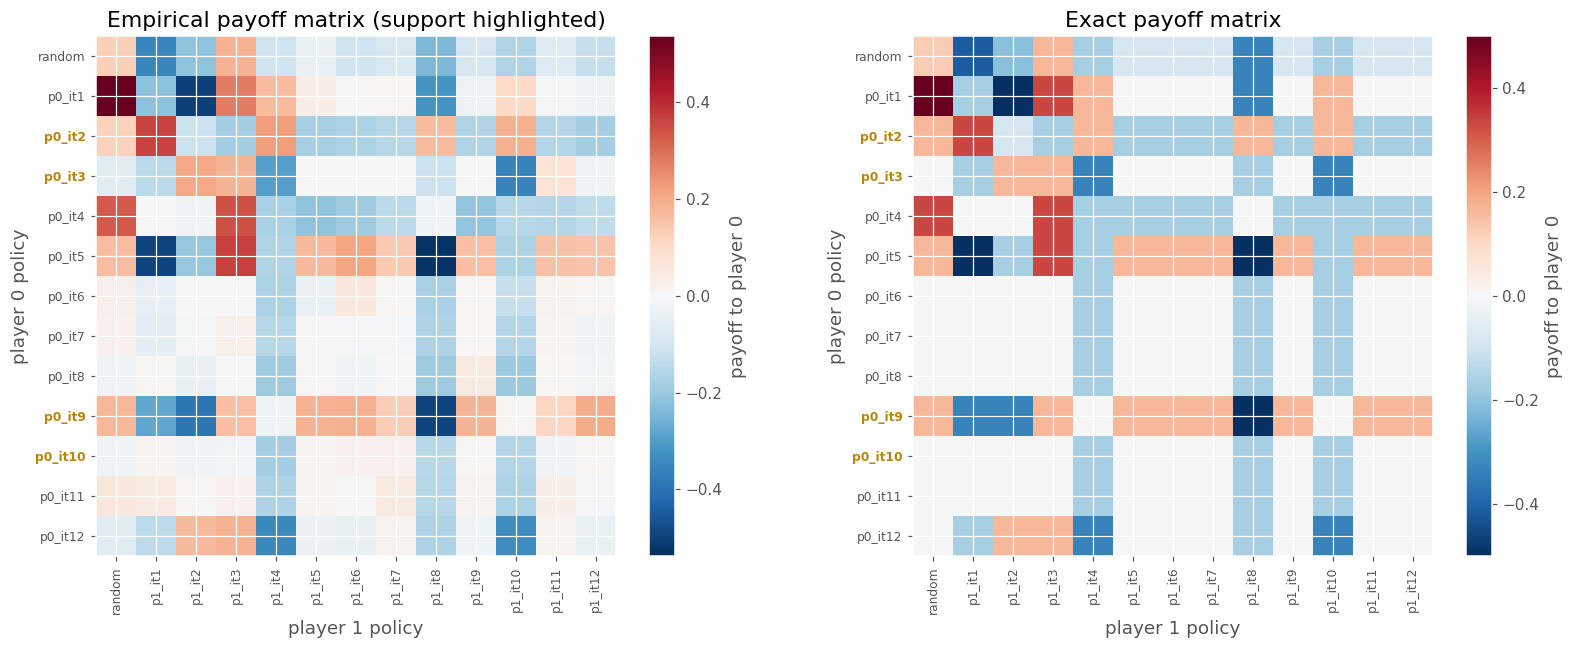

The estimated matrix in numbers (payoff to player 0):


,random,p1_it1,p1_it2,p1_it3,p1_it4,p1_it5,p1_it6,p1_it7,p1_it8,p1_it9,p1_it10,p1_it11,p1_it12
random,0.130,-0.352,-0.215,0.187,-0.108,-0.035,-0.108,-0.083,-0.241,-0.090,-0.161,-0.069,-0.125
p0_it1,0.536,-0.218,-0.500,0.274,0.172,0.034,0.004,0.008,-0.319,-0.028,0.107,-0.010,-0.029
p0_it2,0.124,0.363,-0.116,-0.182,0.224,-0.177,-0.168,-0.155,0.172,-0.161,0.189,-0.157,-0.183
p0_it3,-0.062,-0.146,0.204,0.181,-0.296,-0.002,-0.003,-0.003,-0.115,0.002,-0.357,0.075,-0.019
p0_it4,0.330,0.004,-0.020,0.341,-0.174,-0.216,-0.192,-0.144,-0.017,-0.210,-0.155,-0.158,-0.134
p0_it5,0.167,-0.491,-0.202,0.365,-0.163,0.174,0.213,0.142,-0.527,0.160,-0.170,0.158,0.154
p0_it6,0.028,-0.044,0.001,-0.001,-0.168,-0.035,0.056,0.005,-0.173,0.011,-0.124,0.018,0.010
p0_it7,0.022,-0.049,-0.005,0.027,-0.154,0.006,-0.010,-0.007,-0.164,0.011,-0.159,0.015,-0.024
p0_it8,-0.021,0.006,-0.038,0.003,-0.190,0.005,-0.025,-0.001,-0.190,0.049,-0.200,0.011,-0.014
p0_it9,0.177,-0.279,-0.388,0.160,-0.024,0.186,0.192,0.133,-0.491,0.181,0.006,0.112,0.198


Absolute difference between the estimated and the exact matrix:


,random,p1_it1,p1_it2,p1_it3,p1_it4,p1_it5,p1_it6,p1_it7,p1_it8,p1_it9,p1_it10,p1_it11,p1_it12
random,0.004,0.065,0.007,0.020,0.059,0.048,0.024,0.000,0.093,0.007,0.006,0.014,0.042
p0_it1,0.036,0.052,0.000,0.059,0.005,0.034,0.004,0.008,0.014,0.028,0.060,0.010,0.029
p0_it2,0.042,0.030,0.033,0.015,0.058,0.010,0.001,0.012,0.005,0.006,0.022,0.010,0.016
p0_it3,0.062,0.021,0.037,0.014,0.037,0.002,0.003,0.003,0.052,0.002,0.024,0.075,0.019
p0_it4,0.003,0.004,0.020,0.008,0.008,0.049,0.025,0.023,0.017,0.043,0.012,0.008,0.032
p0_it5,0.001,0.009,0.036,0.032,0.004,0.007,0.047,0.025,0.027,0.007,0.003,0.008,0.012
p0_it6,0.028,0.044,0.001,0.001,0.002,0.035,0.056,0.005,0.006,0.011,0.043,0.018,0.010
p0_it7,0.022,0.049,0.005,0.027,0.013,0.006,0.010,0.007,0.002,0.011,0.008,0.015,0.024
p0_it8,0.021,0.006,0.038,0.003,0.024,0.005,0.025,0.001,0.023,0.049,0.034,0.011,0.014
p0_it9,0.010,0.054,0.055,0.007,0.024,0.019,0.025,0.034,0.009,0.014,0.006,0.054,0.031


Largest estimation error anywhere in the matrix: 0.0928
Policies carrying probability in the solution:


,policy,probability
0,p0_it2,0.3322
1,p0_it3,0.0799
2,p0_it9,0.0361
3,p0_it10,0.5518


Dominated policies, player 0 : none
Dominated policies, player 1 : [0, 3]
Three-cycles among player 0 policies: 10
Fraction of triples that are cyclic : 0.035
Example cycle: random beats p0_it3 (+0.083), p0_it3 beats p0_it2 (+0.167), p0_it2 beats random (+0.167)


In [30]:
exp3 = experiments.experiment_3(seed=SEED)

matrix = np.asarray(exp3['payoff_matrix'])
row_names, column_names = exp3['policy_names']

estimated = np.asarray(exp3['estimated_payoff_matrix'])

figure, axes = plt.subplots(1, 2, figsize=(15, 6))
analysis.plot_payoff_heatmap(estimated, row_names, column_names,
                             meta_strategy=exp3['meta_strategy0'], ax=axes[0],
                             title='Empirical payoff matrix (support highlighted)')
analysis.plot_payoff_heatmap(matrix, row_names, column_names,
                             meta_strategy=exp3['meta_strategy0'], ax=axes[1],
                             title='Exact payoff matrix')
plt.tight_layout()
plt.show()

print('The estimated matrix in numbers (payoff to player 0):')
display(pd.DataFrame(estimated, index=row_names, columns=column_names).round(3))
print('Absolute difference between the estimated and the exact matrix:')
display(pd.DataFrame(np.abs(estimated - matrix),
                     index=row_names, columns=column_names).round(3))
print(f'Largest estimation error anywhere in the matrix: '
      f'{np.abs(estimated - matrix).max():.4f}')

support_table = pd.DataFrame({
    'policy': [row_names[i] for i in exp3['support0']],
    'probability': [round(exp3['meta_strategy0'][i], 4) for i in exp3['support0']],
})
print('Policies carrying probability in the solution:')
display(support_table)

head_to_head = np.asarray(exp3['head_to_head'])
print('Dominated policies, player 0 :', exp3['dominated0'] or 'none')
print('Dominated policies, player 1 :', exp3['dominated1'] or 'none')
print('Three-cycles among player 0 policies:', exp3['cycles']['num_3cycles'])
print('Fraction of triples that are cyclic :',
      round(exp3['cycles']['cyclic_triple_fraction'], 4))

for a, b, c in exp3['cycles']['cycles'][:1]:
    order = (a, b, c) if head_to_head[a, b] > 0 else (a, c, b)
    x, y, z = order
    print(f'Example cycle: {row_names[x]} beats {row_names[y]} '
          f'({head_to_head[x, y]:+.3f}), {row_names[y]} beats {row_names[z]} '
          f'({head_to_head[y, z]:+.3f}), {row_names[z]} beats {row_names[x]} '
          f'({head_to_head[z, x]:+.3f})')

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קריאת המטריצה והתמיכה:</p>
<ul>
<li>ארבע מתוך 13 נושאות משקל: p0_it10 ב-0.5518, p0_it2 ב-0.3322, p0_it3 ב-0.0799 ו-p0_it9 ב-0.0361. התשע האחרות היו יריבות אימון.</li>
<li>שלושה מהמשקלים הם בדיוק פרמטרי Kuhn מסעיף 9.1: 0.3322 היא beta, 0.0799 gamma ו-0.0361 alpha.</li>
<li>לשחקן 0 אין מדיניות נשלטת ולשחקן 1 יש שתיים, עקבי עם שיווי המשקל היחיד שלו שמשאיר פחות מרחב.</li>
<li>עשרה מעגלים בני שלושה, 3.5 אחוז מהשלשות: random מנצח את p0_it3, זה את p0_it2, וזה את random. אין מנצחת יחידה.</li>
<li>השגיאה הגדולה בין הנאמדת למדויקת היא 0.0928, ושתי מפות החום זהות במבנה — הפותר ראה את הנאמדת.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מציג את הגיוון השולי של כל מדיניות — כמה התנהגות חדשה הוסיפה ביחס לקודמותיה. אפס פירושו שהיא משכפלת מדיניות קיימת.</p>
</div>

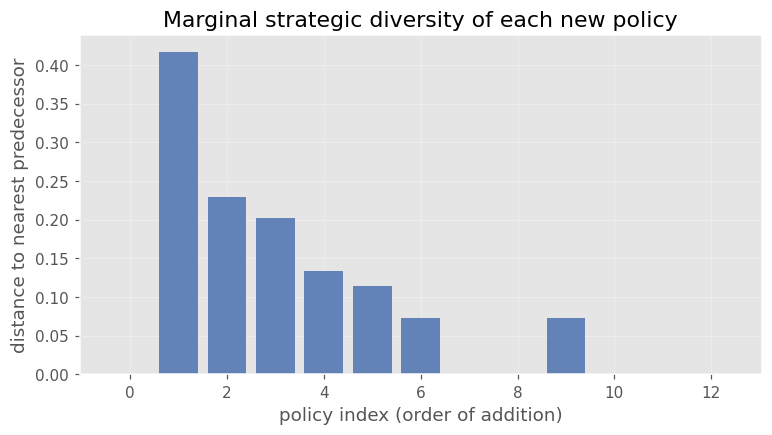

,policy,marginal diversity,in support
0,random,0.0000,False
1,p0_it1,0.4175,False
2,p0_it2,0.2289,True
3,p0_it3,0.2017,True
4,p0_it4,0.1330,False
5,p0_it5,0.1138,False
6,p0_it6,0.0723,False
7,p0_it7,0.0000,False
8,p0_it8,0.0000,False
9,p0_it9,0.0723,True


Policies adding nothing new: 6 of 13


In [31]:
analysis.plot_marginal_diversity(exp3['marginal_diversity'])
plt.show()

diversity_table = pd.DataFrame({
    'policy': row_names[:len(exp3['marginal_diversity'])],
    'marginal diversity': np.round(exp3['marginal_diversity'], 4),
    'in support': [row_names.index(n) in exp3['support0']
                   for n in row_names[:len(exp3['marginal_diversity'])]],
})
display(diversity_table)
print(f'Policies adding nothing new: '
      f'{(diversity_table["marginal diversity"] == 0).sum()} of {len(diversity_table)}')

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קריאת הגיוון השולי:</p>
<ul>
<li>הצניחה מהירה: 0.4175 בשנייה, מתחת ל-0.1 מהשביעית, ואפס בשלוש האחרונות.</li>
<li>שש מתוך 13 מוסיפות אפס, ואחת מהן היא random שאין לה קודמות. הירידה אינה מונוטונית: p0_it9 חוזר ל-0.0723.</li>
<li>הגבוה ביותר הוא p0_it1 ב-0.4175 והוא אינו בתמיכה, ואילו p0_it10 נושא 0.5518 מהמשקל עם גיוון 0.0000.</li>
<li>לכן אפס בגיוון השולי אינו סימן עצירה, וגיוון גבוה אינו מנבא כניסה לפתרון.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10.4 ניסוי 4 — איכות ה-oracle המקורב</p>
<p>ארבעה תקציבי אימון ל-oracle, ובנוסף האורקל המדויק כתקרה: איתו הלולאה היא double oracle שמובטח לעצור בשיווי משקל.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ את חמש התצורות: טבלת סיכום, ה-exploitability לפי איטרציה, ושני גרפים עם קו הייחוס של האורקל המדויק.</p>
</div>

  [1/30] q500_s0
  [2/30] q500_s1
  [3/30] q500_s2
  [4/30] q500_s3
  [5/30] q500_s4
  [6/30] q2000_s0
  [7/30] q2000_s1
  [8/30] q2000_s2
  [9/30] q2000_s3
  [10/30] q2000_s4
  [11/30] q10000_s0
  [12/30] q10000_s1
  [13/30] q10000_s2
  [14/30] q10000_s3
  [15/30] q10000_s4
  [16/30] q50000_s0
  [17/30] q50000_s1
  [18/30] q50000_s2
  [19/30] q50000_s3
  [20/30] q50000_s4
  [21/30] exact_s0
  [22/30] exact_s1
  [23/30] exact_s2
  [24/30] exact_s3
  [25/30] exact_s4
  [26/30] double_oracle_s0
  [27/30] double_oracle_s1
  [28/30] double_oracle_s2
  [29/30] double_oracle_s3
  [30/30] double_oracle_s4
Oracle budget comparison:


,final_exploitability,value_error,support,population,diversity_weighted,total_oracle_episodes,wall_seconds,expl. std,expl. 95% CI
group,,,,,,,,,
double_oracle,0.0000,0.0000,3.0,13.0,0.2468,0.0,0.2259,0.0000,0.0000
exact_oracle,0.0128,0.0003,5.2,13.0,0.2545,0.0,0.4165,0.0063,0.0078
q_learning_500,0.0429,0.0040,4.8,13.0,0.2316,12000.0,0.8000,0.0360,0.0447
q_learning_2000,0.0598,0.0044,5.4,13.0,0.2222,48000.0,2.8895,0.0218,0.0270
q_learning_10000,0.0448,0.0011,6.0,13.0,0.2017,240000.0,12.2466,0.0151,0.0187
q_learning_50000,0.0281,0.0002,5.0,13.0,0.2234,1200000.0,60.0427,0.0111,0.0137


Exploitability by iteration (mean over seeds):


group,double_oracle,exact_oracle,q_learning_10000,q_learning_2000,q_learning_500,q_learning_50000
iteration,,,,,,
1,0.9167,0.9167,0.9167,0.9167,0.9167,0.9167
2,0.8333,0.8333,0.7000,0.7500,0.6833,0.7667
3,0.3333,0.3333,0.3612,0.3724,0.3563,0.3504
4,0.1833,0.1825,0.3033,0.2868,0.2772,0.2813
5,0.2222,0.1830,0.2401,0.1839,0.2231,0.1777
6,0.1354,0.1419,0.1269,0.1255,0.1617,0.1445
7,0.0000,0.0390,0.1021,0.1170,0.1344,0.0632
8,0.0000,0.0216,0.0511,0.0659,0.0864,0.0197
9,0.0000,0.0214,0.0367,0.0864,0.0539,0.0244


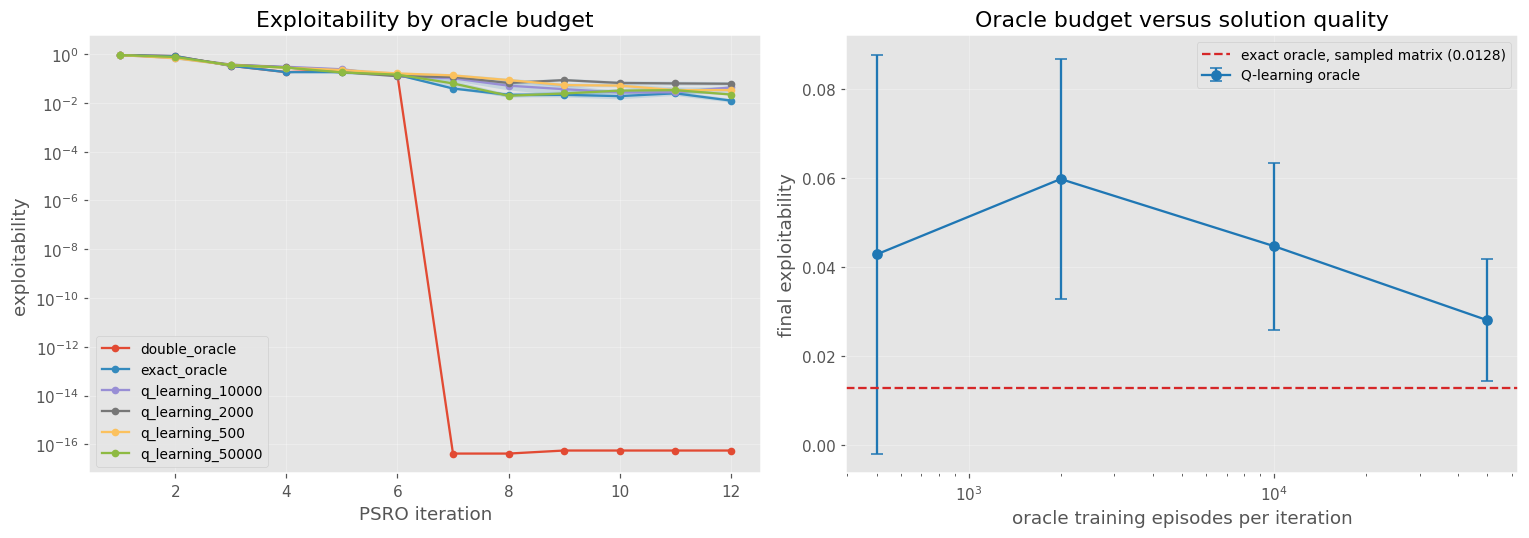

In [32]:
exp4_iterations, exp4_summary = experiments.experiment_4(budgets=ORACLE_BUDGETS,
                                                         seeds=EXP_SEEDS)

half_width = stats.t.ppf(0.975, df=len(EXP_SEEDS) - 1)

metrics = ['final_exploitability', 'value_error', 'support', 'population',
           'diversity_weighted', 'total_oracle_episodes', 'wall_seconds']
exp4_table = exp4_summary.groupby('group')[metrics].mean().round(4)
exp4_table['expl. std'] = exp4_summary.groupby('group')['final_exploitability'].std().round(4)
exp4_table['expl. 95% CI'] = (
    half_width * exp4_summary.groupby('group')['final_exploitability'].sem()).round(4)
print('Oracle budget comparison:')
display(exp4_table.sort_values('total_oracle_episodes'))

print('Exploitability by iteration (mean over seeds):')
display(exp4_iterations.pivot_table(index='iteration', columns='group',
                                    values='exploitability', aggfunc='mean').round(4))

figure, axes = plt.subplots(1, 2, figsize=(14, 5))
analysis.plot_metric_by_iteration(exp4_iterations, 'exploitability', ax=axes[0],
                                  title='Exploitability by oracle budget',
                                  ylabel='exploitability')
learned = exp4_summary[exp4_summary['oracle'] == 'q_learning']
axes[1].errorbar(learned.groupby('budget')['budget'].first(),
                 learned.groupby('budget')['final_exploitability'].mean(),
                 yerr=half_width * learned.groupby('budget')['final_exploitability'].sem(),
                 marker='o', capsize=4, color='#1f77b4', label='Q-learning oracle')
exact_level = exp4_summary.loc[exp4_summary['group'] == 'exact_oracle',
                               'final_exploitability'].mean()
axes[1].axhline(exact_level, color='#d62728', linestyle='--',
                label=f'exact oracle, sampled matrix ({exact_level:.4f})')
axes[1].set_xscale('log')
axes[1].set_xlabel('oracle training episodes per iteration')
axes[1].set_ylabel('final exploitability')
axes[1].set_title('Oracle budget versus solution quality')
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח ניסוי 4:</p>
<ul>
<li>double_oracle מגיע ל-0.0000 באיטרציה 7, באפס אפיזודות אימון ו-0.1501 שניות. תגובה מיטבית מדויקת אינה דורשת למידה.</li>
<li>התקציב הגדול, 1.2 מיליון אפיזודות ו-53.9090 שניות, מגיע ל-0.0281 — פי 359 זמן, ותוצאה גרועה לאין שיעור.</li>
<li>הדירוג בין התקציבים אינו מונוטוני — 0.0429, 0.0598, 0.0448, 0.0281 — ורווח הסמך של 500 חוצה אפס, כלומר אינו מפריד כלל.</li>
<li>מה שכן מונוטוני הוא סטיית התקן: 0.0360, 0.0218, 0.0151, 0.0111, ואפס ב-double oracle. התקציב קונה יציבות.</li>
<li>שגיאת הערך יורדת מ-0.0040 ל-0.0002 אך לא מונוטונית — 2,000 מחמיר ל-0.0044 לפני שהמגמה מתהפכת.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10.4.1 פירוק שגיאה: מה בדיוק מפריד בין PSRO למשפט</p>
<p>PSRO סוטה מ-double oracle בשלושה מקומות, ובמשחק בגודל של Kuhn אפשר לכבות כל אחד ולמדוד את מחירו.</p>
<ul>
<li>שלוש הסטיות: האסטרטגיות הן מדיניויות ולא אסטרטגיות טהורות, התגובה המיטבית נלמדת ולא מחושבת, ומטריצת התגמולים נדגמת.</li>
<li>שלוש הזרועות: q_learning ו-exact_oracle עם מטריצה נדגמת, ו-double_oracle שבו הכול מדויק — האלגוריתם של McMahan, וקו האפס.</li>
<li>טענה 1 של McAleer ואחרים (NeurIPS 2021): אורקל עד כדי epsilon_1 ופתירה עד כדי epsilon_2 נותנים שיווי משקל עד כדי סכומם.</li>
<li>הספרות אינה מבודדת את השפעת תקציב האורקל על ה-exploitability הסופי, ולכן זו תרומה קטנה ולא רק אבלציה.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מפרק את השגיאה הנותרת לשני מקורותיה — דגימת המטריצה וקירוב התגובה המיטבית — ומכמת כל אחד.</p>
</div>

,final_exploitability,population_exploitability,value_error,total_oracle_episodes,total_eval_episodes,wall_seconds,exploitability std
group,,,,,,,
double_oracle,0.0000,-0.0000,0.0000,0.0,0.0,0.2259,0.0000
exact_oracle,0.0128,0.0000,0.0003,0.0,338000.0,0.4165,0.0063
q_learning_10000,0.0448,-0.0000,0.0011,240000.0,338000.0,12.2466,0.0151
q_learning_2000,0.0598,0.0056,0.0044,48000.0,338000.0,2.8895,0.0218
q_learning_500,0.0429,0.0032,0.0040,12000.0,338000.0,0.8000,0.0360
q_learning_50000,0.0281,-0.0000,0.0002,1200000.0,338000.0,60.0427,0.0111


Where the residual exploitability comes from:
  exact oracle + exact payoffs (double oracle) : 5.55e-17
  exact oracle + sampled payoffs              : 0.0128
  learned oracle + sampled payoffs (best)     : 0.0281

  cost of sampling the payoff matrix          : 0.0128
  cost of approximating the best response     : 0.0153
  ratio                                       : 1.20x


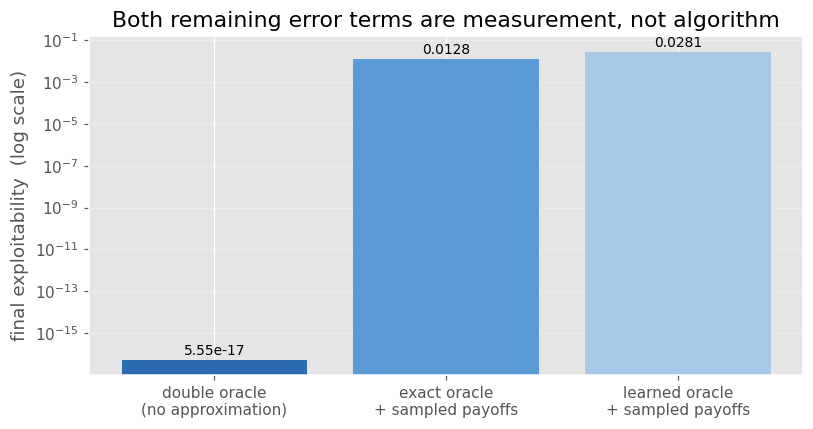

In [33]:
groups = exp4_summary.groupby('group')
group_means = groups[['final_exploitability', 'population_exploitability',
                      'value_error', 'total_oracle_episodes',
                      'total_eval_episodes', 'wall_seconds']].mean()
decomposition = group_means.round(4)
decomposition['exploitability std'] = groups['final_exploitability'].std(ddof=1).round(4)
display(decomposition)

double_oracle = group_means.loc['double_oracle', 'final_exploitability']
exact_sampled = group_means.loc['exact_oracle', 'final_exploitability']
best_learned = group_means.loc[
    [i for i in group_means.index if i.startswith('q_learning')],
    'final_exploitability'].min()

print('Where the residual exploitability comes from:')
print(f'  exact oracle + exact payoffs (double oracle) : {double_oracle:.2e}')
print(f'  exact oracle + sampled payoffs              : {exact_sampled:.4f}')
print(f'  learned oracle + sampled payoffs (best)     : {best_learned:.4f}')
sampling_cost = exact_sampled - double_oracle
oracle_cost = best_learned - exact_sampled
print()
print(f'  cost of sampling the payoff matrix          : {sampling_cost:.4f}')
print(f'  cost of approximating the best response     : {oracle_cost:.4f}')
print(f'  ratio                                       : '
      f'{max(sampling_cost, oracle_cost) / max(min(sampling_cost, oracle_cost), 1e-12):.2f}x')

fig, ax = plt.subplots(figsize=(7.5, 4))
labels = ['double oracle\n(no approximation)', 'exact oracle\n+ sampled payoffs',
          'learned oracle\n+ sampled payoffs']
values = [max(double_oracle, 1e-17), exact_sampled, best_learned]
ax.bar(labels, values, color=['#2b6cb0', '#5a9bd5', '#a8c8e8'])
ax.set_yscale('log')
ax.set_ylabel('final exploitability  (log scale)')
ax.set_title('Both remaining error terms are measurement, not algorithm')
ax.grid(alpha=0.3, axis='y')
for index, value in enumerate(values):
    ax.text(index, value * 1.6, f'{value:.2e}' if value < 1e-6 else f'{value:.4f}',
            ha='center', fontsize=9)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>קריאת הפירוק:</p>
<ul>
<li>double_oracle מגיע ל-5.55e-17, אפס של מכונה. האלגוריתם עצמו אינו תורם שגיאה, ושני האיברים שנותרו הם מדידה.</li>
<li>המעבר מ-double_oracle לזרוע עם מטריצה נדגמת הוא כל מחיר הדגימה: אותו אורקל מדויק, אותו פותר, אותן איטרציות.</li>
<li>שני האיברים מאותו סדר גודל: 0.0128 לדגימת המטריצה מול 0.0153 לקירוב התגובה המיטבית, יחס של 1.20.</li>
<li>זה מנוגד לאינטואיציה שלפיה האורקל הוא הרכיב הקשה, והמסקנה המעשית היא שאסור להשקיע תקציב רק באחד משניהם.</li>
<li>population_exploitability אפס בארבע זרועות אך 0.0056 ב-2,000 ו-0.0032 ב-500: בתקציב נמוך האוכלוסייה עצמה חסרה.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>10.5 ניסוי 5 — הכללה ליריבים שלא נראו</p>
<p>שלוש משפחות היריבים: הבייסליינים, שמונה מדיניות אקראיות מזרע נפרד, ושלוש הפרעות של שיווי המשקל ברמות רעש שונות. נמדדים גם ביצועים מול מדיניות מוקדמות של האוכלוסייה ומול שיווי המשקל.</p>
<p>המדד הקריטי הוא המקרה הגרוע ולא הממוצע: סוכן חסין הוא כזה שאין לו נקודת תורפה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מציג שתי טבלאות הכללה, ממוצע ומקרה גרוע, ואת שני החתכים גם כגרפים.</p>
</div>

  [1/20] self_play_s0
  [2/20] self_play_s1
  [3/20] self_play_s2
  [4/20] self_play_s3
  [5/20] self_play_s4
  [6/20] uniform_s0
  [7/20] uniform_s1
  [8/20] uniform_s2
  [9/20] uniform_s3
  [10/20] uniform_s4
  [11/20] nash_s0
  [12/20] nash_s1
  [13/20] nash_s2
  [14/20] nash_s3
  [15/20] nash_s4
  [16/20] projected_replicator_s0
  [17/20] projected_replicator_s1
  [18/20] projected_replicator_s2
  [19/20] projected_replicator_s3
  [20/20] projected_replicator_s4
Mean payoff against each held-out opponent family:


,vs_baselines_mean,vs_unseen_mean,vs_perturbed_mean,vs_nash_mean
group,,,,
nash,0.0469,0.1001,-0.0136,-0.0556
projected_replicator,0.0436,0.0793,-0.0186,-0.0569
self_play,0.1333,0.4347,0.0576,-0.0778
uniform,0.0647,0.1339,-0.0128,-0.0744


Worst-case payoff, and sensitivity to opponent choice:


,vs_baselines_worst,vs_unseen_worst,vs_perturbed_worst,vs_early_worst,vs_unseen_spread
group,,,,,
nash,-0.0483,0.0538,-0.0407,-0.0326,0.0301
projected_replicator,-0.0558,0.0304,-0.0434,-0.0322,0.0319
self_play,0.0000,0.0965,-0.0300,-0.4167,0.2465
uniform,-0.0833,0.0775,-0.0526,-0.0577,0.0488


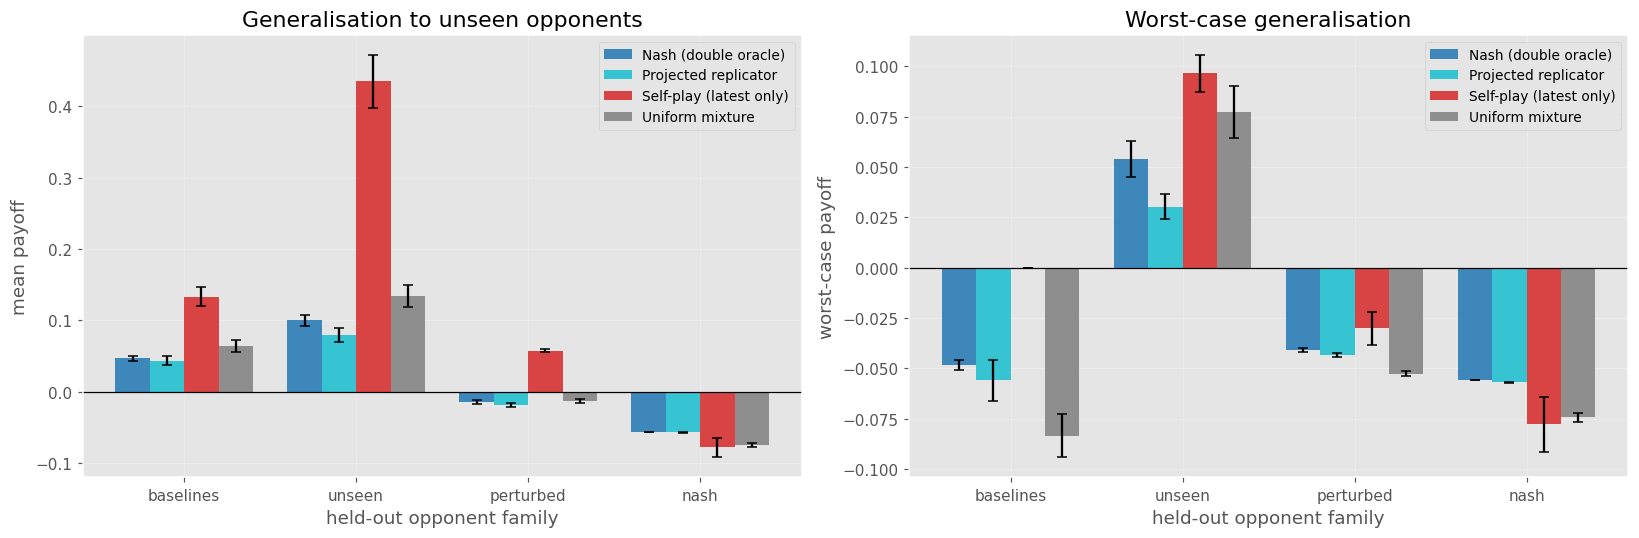

In [34]:
exp5_iterations, exp5_summary = experiments.experiment_5(seeds=EXP_SEEDS)

mean_columns = ['vs_baselines_mean', 'vs_unseen_mean', 'vs_perturbed_mean',
                'vs_nash_mean']
worst_columns = ['vs_baselines_worst', 'vs_unseen_worst', 'vs_perturbed_worst',
                 'vs_early_worst']
print('Mean payoff against each held-out opponent family:')
display(exp5_summary.groupby('group')[mean_columns].mean().round(4))
print('Worst-case payoff, and sensitivity to opponent choice:')
display(exp5_summary.groupby('group')[worst_columns + ['vs_unseen_spread']]
        .mean().round(4))

figure, axes = plt.subplots(1, 2, figsize=(15, 5))
analysis.plot_generalisation(exp5_summary, ax=axes[0])
analysis.plot_generalisation(exp5_summary, worst_case=True, ax=axes[1])
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח ניסוי 5:</p>
<ul>
<li>self_play מוביל בכל שלושת הממוצעים — 0.1333, 0.4347 ו-0.0576 — כי מדיניות טהורה ותוקפנית גובה מיריב חלש ביד רחבה.</li>
<li>אבל ה-exploitability שלו 1.2500 מול 0.0315: הוא גובה 0.4347 מיריב אקראי ומפסיד 1.2500 למי שמנצל אותו.</li>
<li>מול שיווי המשקל nash מקבל בדיוק 0.0556-, ערך המשחק. כל השאר מפסידים יותר: 0.0569-, 0.0744- ו-0.0778-.</li>
<li>המדד שמפיל אותו הוא מול גרסאות מוקדמות של עצמו, 0.4167- מול 0.0326-; בשלוש העמודות האחרות הוא דווקא הטוב ביותר.</li>
<li>projected_replicator הוא הגרוע ביותר מול יריבים שלא נראו במקרה הגרוע, 0.0304 מול 0.0538 ב-nash.</li>
<li>exploitability והכללה אינם אותו מדד, ואסור לדווח רק אחד. הבחירה ביניהם היא בחירה בתרחיש השימוש.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>11. מחקר אבלציות (סעיף 8 במפרט)</p>
<p>המפרט דורש לפחות שתיים; כאן חמש אבלציות מול זרוע ייחוס, כל אחת משנה רכיב אחד בדיוק והשאר נשאר זהה, כך שההפרש מיוחס לו.</p>
<ul>
<li>full — זרוע הייחוס, PSRO מלא עם פותר נאש</li>
<li>no_population — הסרת האוכלוסייה, אימון מול המדיניות האחרונה בלבד</li>
<li>uniform_meta — החלפת המטא-אסטרטגיה הנלמדת בתערובת אחידה</li>
<li>few_eval_episodes — הפחתת אפיזודות ההערכה פי 10, כלומר מטריצת תגמולים רועשת</li>
<li>weak_oracle — הפחתת תקציב האימון פי 10</li>
<li>heuristic_start — התחלה מאוכלוסייה היוריסטית במקום אקראית</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מריץ את שש הזרועות ומציג שלוש טבלאות: הערכים המוחלטים, ההפרש מזרוע הייחוס, והיחס אליה. אחריהן העקומות וגרף העמודות.</p>
</div>

  [1/30] full_s0
  [2/30] full_s1
  [3/30] full_s2
  [4/30] full_s3
  [5/30] full_s4
  [6/30] no_population_s0
  [7/30] no_population_s1
  [8/30] no_population_s2
  [9/30] no_population_s3
  [10/30] no_population_s4
  [11/30] uniform_meta_s0
  [12/30] uniform_meta_s1
  [13/30] uniform_meta_s2
  [14/30] uniform_meta_s3
  [15/30] uniform_meta_s4
  [16/30] few_eval_episodes_s0
  [17/30] few_eval_episodes_s1
  [18/30] few_eval_episodes_s2
  [19/30] few_eval_episodes_s3
  [20/30] few_eval_episodes_s4
  [21/30] weak_oracle_s0
  [22/30] weak_oracle_s1
  [23/30] weak_oracle_s2
  [24/30] weak_oracle_s3
  [25/30] weak_oracle_s4
  [26/30] heuristic_start_s0
  [27/30] heuristic_start_s1
  [28/30] heuristic_start_s2
  [29/30] heuristic_start_s3
  [30/30] heuristic_start_s4
Absolute values:


,final_exploitability,vs_unseen_worst,vs_perturbed_worst,support,entropy,diversity_weighted,value_error,expl. 95% CI
group,,,,,,,,
heuristic_start,0.0220,0.0585,-0.0404,5.2,1.4945,0.2163,0.0004,0.0063
full,0.0315,0.0538,-0.0407,4.4,1.1686,0.2277,0.0004,0.0150
weak_oracle,0.0429,0.0664,-0.0392,4.8,1.3278,0.2316,0.0040,0.0447
few_eval_episodes,0.0786,0.0504,-0.0417,5.8,1.5574,0.2092,0.0066,0.0387
uniform_meta,0.1462,0.0775,-0.0526,13.0,2.5649,0.2098,0.0121,0.0469
no_population,1.2500,0.0965,-0.0300,1.0,0.0000,0.0000,0.8056,0.0000


Difference from the reference arm (full):


,final_exploitability,vs_unseen_worst,vs_perturbed_worst,support,entropy,diversity_weighted,value_error
group,,,,,,,
no_population,1.2185,0.0426,0.0107,-3.4,-1.1686,-0.2277,0.8051
uniform_meta,0.1146,0.0236,-0.0119,8.6,1.3963,-0.0179,0.0117
few_eval_episodes,0.0471,-0.0034,-0.0009,1.4,0.3887,-0.0185,0.0062
weak_oracle,0.0114,0.0126,0.0016,0.4,0.1592,0.0040,0.0035
full,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
heuristic_start,-0.0096,0.0047,0.0003,0.8,0.3258,-0.0114,-0.0001


Exploitability ratio to the reference arm:


,ratio
group,
no_population,39.67
uniform_meta,4.64
few_eval_episodes,2.50
weak_oracle,1.36
full,1.00
heuristic_start,0.70


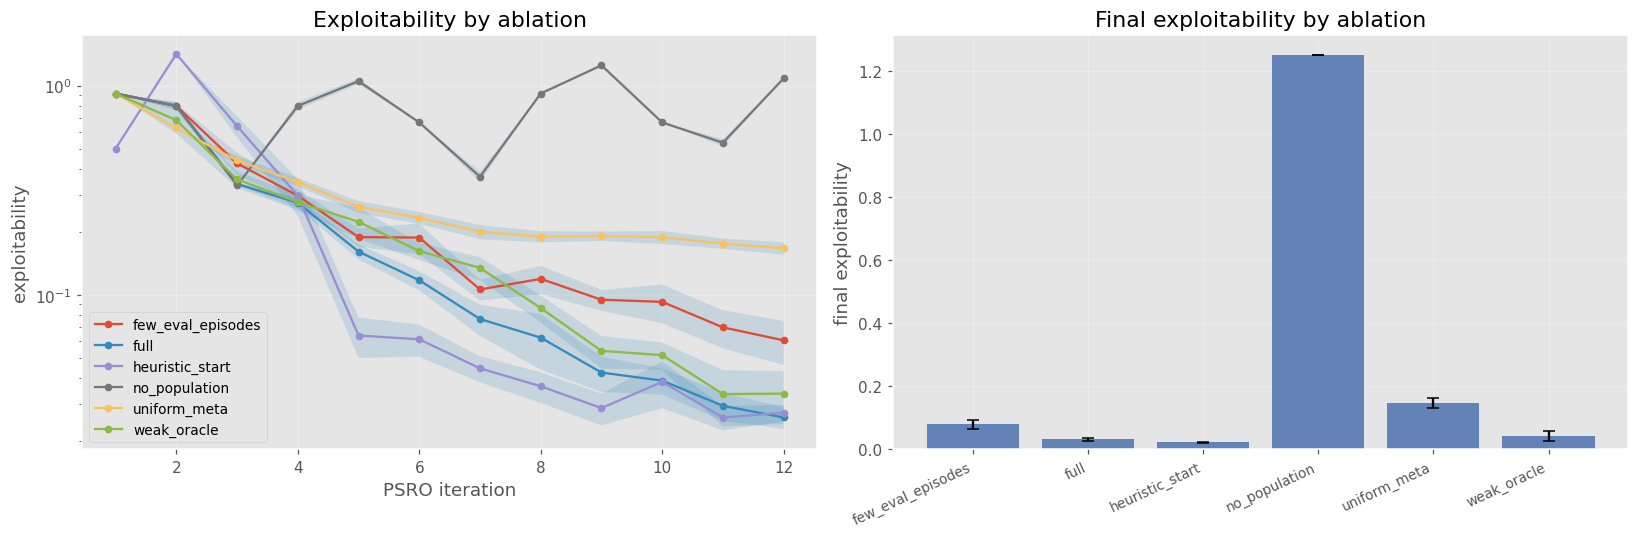

In [35]:
abl_iterations, abl_summary = experiments.ablations(seeds=EXP_SEEDS)

metrics = ['final_exploitability', 'vs_unseen_worst', 'vs_perturbed_worst',
           'support', 'entropy', 'diversity_weighted', 'value_error']
half_width = stats.t.ppf(0.975, df=len(EXP_SEEDS) - 1)
abl_means = abl_summary.groupby('group')[metrics].mean()
reference = abl_means.loc['full']

abl_table = abl_means.round(4)
abl_table['expl. 95% CI'] = (
    half_width * abl_summary.groupby('group')['final_exploitability'].sem()).round(4)
print('Absolute values:')
display(abl_table.sort_values('final_exploitability'))

print('Difference from the reference arm (full):')
display((abl_means - reference).round(4).sort_values('final_exploitability',
                                                     ascending=False))

ratio = abl_means['final_exploitability'] / reference['final_exploitability']
print('Exploitability ratio to the reference arm:')
display(ratio.round(2).sort_values(ascending=False).to_frame('ratio'))

figure, axes = plt.subplots(1, 2, figsize=(15, 5))
analysis.plot_metric_by_iteration(abl_iterations, 'exploitability', ax=axes[0],
                                  title='Exploitability by ablation')
analysis.plot_summary_bars(abl_summary, 'final_exploitability', ax=axes[1],
                           title='Final exploitability by ablation')
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח האבלציות:</p>
<ul>
<li>סדר החשיבות: האוכלוסייה פי 39.67, פתירת המטא-משחק פי 4.64, דיוק ההערכה פי 2.50, וחוזק האורקל פי 1.36.</li>
<li>אבל רק שני הראשונים מופרדים: הרווח של full הוא 0.0150 ושל uniform_meta 0.0469, והטווחים אינם נחתכים.</li>
<li>weak_oracle ו-heuristic_start אינם מופרדים מ-full: רווחיהם 0.0447 ו-0.0063 מול 0.0150. פי 1.36 ופי 0.70 אינם מוכחים.</li>
<li>few_eval_episodes ב-0.0786 עם רווח 0.0387 נוגע בקצה של full — פי 2.50 על הגבול.</li>
<li>no_population עם רווח 0.0000 — חמש ההרצות זהות, כי self_play עם אורקל מדויק דטרמיניסטי.</li>
<li>heuristic_start פותח מתחת לכולם בגרף השמאלי — הוא מתחיל מלפנים ולא לומד מהר יותר.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>התא הבא מונה את הקבצים שהמחברת ייצרה בתיקיות results ו-configs, עם גודלם וזמן הריצה הכולל.</p>
</div>

In [36]:
print(f'Total experiment time: {(time.time() - experiments_started) / 60:.1f} minutes')
print()

rows = []
for folder in ('results', 'configs'):
    path = os.path.join(PATH, folder)
    if not os.path.isdir(path):
        print(f'{folder}/ was not created')
        continue
    for name in sorted(os.listdir(path)):
        rows.append({'folder': folder, 'file': name,
                     'KB': round(os.path.getsize(os.path.join(path, name)) / 1024, 1)})
outputs_table = pd.DataFrame(rows)
display(outputs_table)
print(f'{len(outputs_table)} files, {outputs_table["KB"].sum():.0f} KB in total')

Total experiment time: 23.8 minutes



,folder,file,KB
0,results,ablations.csv,68.0
1,results,ablations_extra.json,242.9
2,results,ablations_summary.csv,27.5
3,results,experiment1_selfplay_vs_psro.csv,20.2
4,results,experiment1_selfplay_vs_psro_extra.json,3.3
5,results,experiment1_selfplay_vs_psro_summary.csv,8.9
6,results,experiment2_metasolvers.csv,93.8
7,results,experiment2_metasolvers_extra.json,330.4
8,results,experiment2_metasolvers_summary.csv,36.5
9,results,experiment3_population.csv,2.3


23 files, 1460 KB in total


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>ניתוח התוצרים:</p>
<ul>
<li>23 קבצים ו-1460 קילובייט: 17 ב-results ושישה ב-configs, קובץ קונפיגורציה לכל ניסוי ולאבלציות.</li>
<li>קובצי ה-extra.json הם 1004 קילובייט מהסך, ושם יושבות מטריצות התגמולים והמטא-אסטרטגיות של כל ניסוי.</li>
<li>לניסוי 3 אין summary.csv כי הוא רץ על seed יחיד, בעוד לכל השאר יש טבלת סיכום על חמישה.</li>
<li>זמן הריצה 23.8 דקות מעיד שהכול חושב מאפס, בהתאם ל-Existing results: none; אם results קיימת המחברת טוענת אותה ורצה בכדקה.</li>
<li>יחד עם קובצי ה-py, המחברת, ה-README, הדוח והמצגת אלה כל התוצרים שסעיף 9 דורש.</li>
</ul>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<p>12. סיכום ומסקנות</p>
<ul>
<li>PSRO מגיע ל-0.0315 מול 1.2500 ב-self-play, פי 39.7, בלי חפיפה על פני חמישה seeds. שגיאת הערך 0.0004 מול 0.8056.</li>
<li>המחזוריות נמדדת ישירות: self-play מפסיד 0.4167- לגרסאות מוקדמות של עצמו מול 0.0326- ב-PSRO, פי שלוש-עשרה.</li>
<li>אבל מול יריבים חלשים שלא נראו self-play מנצח יותר, 0.0965 מול 0.0538 — ההבחנה בין חוסן לניצול.</li>
<li>הראיה החזקה ביותר התנהגותית: שארית 0.0372 מהישר של Kuhn ו-0.0533 מ-(1/3, 1/3), בלי ששום מודול אימון מזכיר את המשפחה.</li>
<li>המבנה תומך: 10 מעגלים לא-טרנזיטיביים, ולכן אין מדיניות שמנצחת את כולן והפתרון חייב להיות תערובת של 4.4.</li>
<li>האבלציות: אוכלוסייה פי 39.67 ופתירה פי 4.64 מופרדות, הערכה פי 2.50 על הגבול, אורקל פי 1.36 ברעש. התקציב הולך למבנה.</li>
<li>הפירוק: double oracle מגיע ל-5.55e-17, ושני האיברים שנותרו הם מדידה — 0.0128 לדגימה מול 0.0153 לאורקל.</li>
<li>שחזור כשל מתועד: rectified_nash מגיע ל-0.5178 ומגלה 5.4 מדיניויות שונות מתוך 13 — הכשל של Muller ואחרים.</li>
<li>אימות חיצוני: המחשבון מסכים לדיוק מכונה עם 11/12 ו-2, שני קבועים מערכת הבדיקה של OpenSpiel.</li>
<li>מגבלות: המשחק קטן, 12 איטרציות, חמישה seeds אינם מפרידים 0.0315 מ-0.0282, וההתכנסות המהירה היא תכונה של Kuhn (Zhang ו-Sandholm, IJCAI 2024).</li>
<li>כיווני המשך: Leduc Poker, PSRO לסכום כללי, Pipeline PSRO, ו-Anytime PSRO שפותר את אי-המונוטוניות שנמדדה כאן.</li>
<li>מטלות 1 עד 3 ענו על אי-הסטציונריות במרחב הפעולות; הפרויקט עונה במרחב המדיניות — אוכלוסייה שנפתרת כמשחק.</li>
</ul>
</div>